# UNDER DEVELOPMENT Example notebook for optimize module

In the following we exemplify how to utilize the optimize module of pyMOE which uses gradient descent methods for inverse design of masks. 

The idea is that the mask pixels can be iteratively changed to minimize of a loss function which evaluates the simulated propagated field from the mask against a target response. A gradient descent method changes the mask pixels iteratively in the direction of the gradient until a certain tolerance is met. Some metrics can be used for loss function constructions. Examples of simple loss functions are the root mean square error (RMSE) or the maximum likelihood estimator. pyMOE optimize module calculates the gradient through JAX package, employing scipy or optax (JAX) optimization frameworks, being extremelly versatile, allowing the user to pick different propagation methods for the task.    

Further documentation will be updated in future releases 

In [1]:
# Notebook display options, change as your preference/system
%matplotlib inline
%config InlineBackend.print_figure_kwargs={'facecolor' : "w",'bbox_inches':None}

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120

In [2]:
# Notebook display options, change as your preference/syste

import sys
sys.path.insert(0,'..')
sys.path.insert(0,'../..')

from matplotlib import pyplot as plt 
import numpy as np 

from scipy.constants import micro, nano, milli

import pyMOE as moe 
from pyMOE.generate import *  
from pyMOE.propagate import * 
from pyMOE.metrics import * 
from pyMOE.optimizer import * 
from pyMOE.ensemble import * 

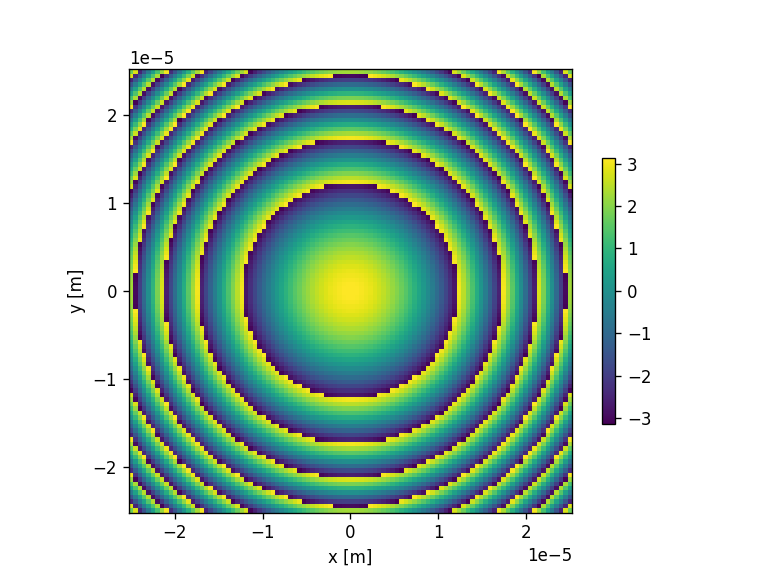

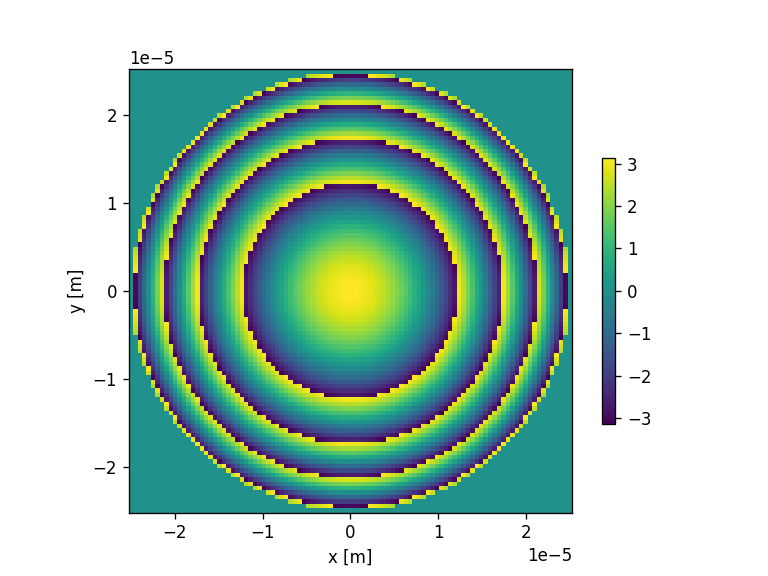

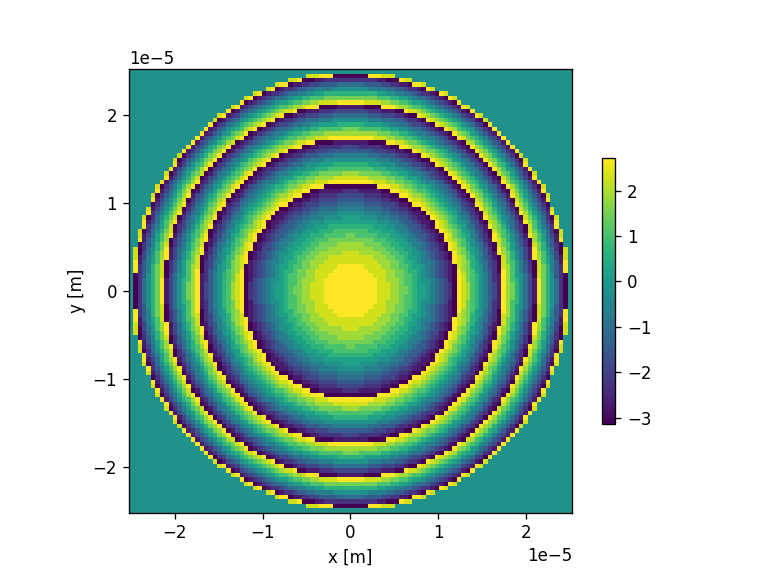

In [3]:
# First just for initialization purpose we will initalize a Fresnel lens 

#number of pixels 
x_pixel = 100
y_pixel = 100

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 150e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture_from_aperture(aperture1)

# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
moe.plotting.plot_aperture(mask2)

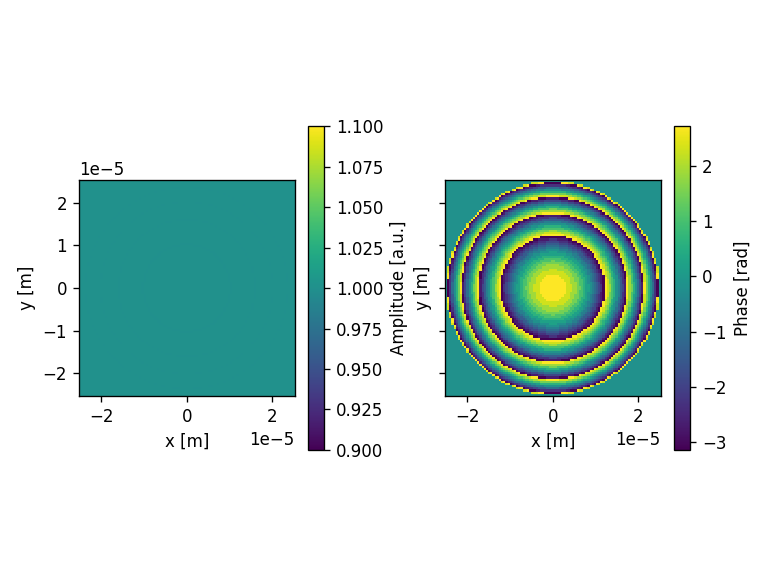

In [4]:
# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )

# Plots the field (amplitude and phase)
moe.plotting.plot_field(field)

plt.tight_layout()
plt.show()


In [5]:
#Initial guess matrix

x_pixel, y_pixel = 100, 100


x0 = np.random.rand(x_pixel, y_pixel) 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
 

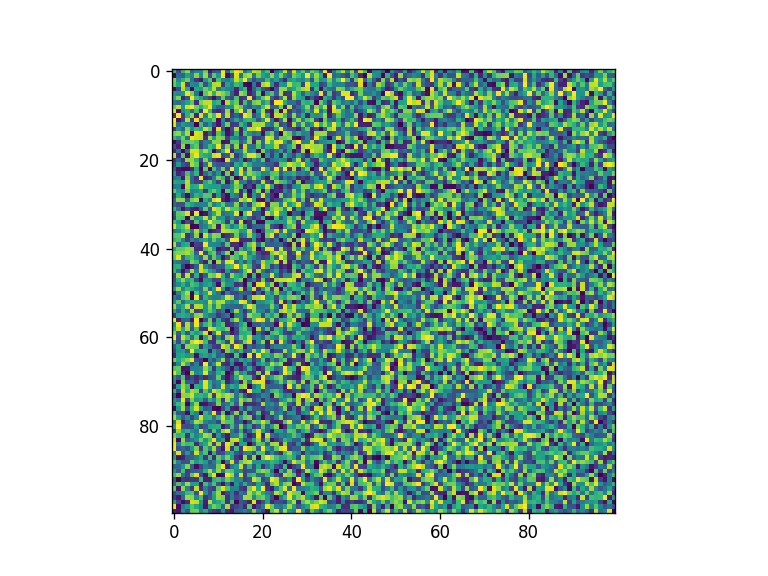

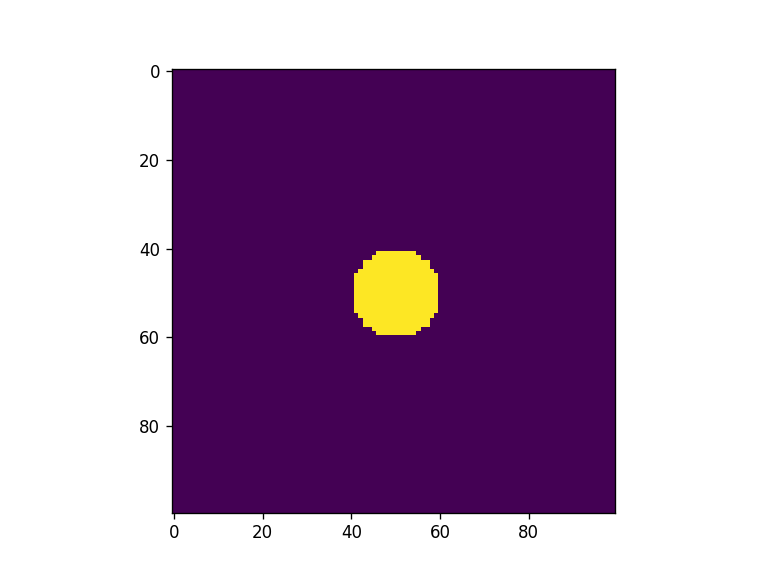

In [6]:
#create target matrix (central cricular pattern) 

matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

In [7]:
#Define Screen 

# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

focal_length = 0.02

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

#### Optimization framework

The optimization framework passes through the definition of loss functions (FOM). Here simply they compare the propagation against a defined target. The loss function takes the propagation method as parameter, so it that different parameters can be tested. 

In [8]:
#Define loss functions 

def FOM(x, mask, screen, wavelength, mat=matrix_flat, propag="bluestein"):
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag).flatten())
    res = np.log(np.sum(((prop_x/np.max(prop_x)-mat/np.max(mat))**2)))
    #print(res)
    return re


def FOM2(x, mask, screen, wavelength, mat=matrix_flat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x = np.abs(moe.optimizer.propagate(np.reshape(x, (x_pixel, y_pixel)), mask, screen, wavelength, propagation_method=propag).flatten())
    prop_x = np.reshape(prop_x, (x_pixel, y_pixel))
    midx, midy = int(x_pixel/2), int(y_pixel/2)
    mat = np.reshape(mat, (x_pixel, y_pixel))
    
    res = np.log(np.sum(((prop_x/np.max(prop_x)/(prop_x[(midx,midy)]/np.max(prop_x)) - mat/np.max(mat))**2)))
    
    #print(res, prop_x[(midx,midy)])#(prop_x[midx]/np.max(prop_x)-mat[midy]/np.max(mat))**2)
    return res


def FOM3(x, mask, screen, wavelength, mat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag))
    
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = np.sum(diff)
    #print(res)
    
    return res



In [9]:
# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

#fig = plt.figure() 
#plt.imshow(np.abs(np.array(propagate(mask2.aperture, mask2, screen, wavelength) ) ))

In [10]:
# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -aperture_height/2, aperture_height/2
xmin, xmax = -aperture_width/2, aperture_width/2

# the distance (called focal_length by chance, we are not focusing here) 
# is maintained in a range that is close enough so that ASM and SASM can be used without much troubles 
focal_length = 0.00015

x = np.linspace(xmin, xmax, x_pixel)
y = np.linspace(ymin, ymax, y_pixel)
z = np.array([focal_length])


screen = moe.field.Screen(x,y,z)

Below we demonstrate several optimizations using Bluestein, ASM and SASM propagators. All of them yield acceptable inverse designed masks. 

Elapsed: 0:00:01.148960
Elapsed: 0:00:00.292719
Elapsed: 0:00:00.016926
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.041817
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.044805
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.038825
Elapsed: 0:00:00.020411
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.040820
Elapsed: 0:00:00.025389
Elapsed: 0:00:00.061729
Elapsed: 0:00:00.016927
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.039327
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.054759
Elapsed: 0:00:00.071686
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.053765
Elapsed: 0:00:00.014438
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.046795
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.052768
Elapsed: 0:00:00.019913
Elapsed: 0:00:00.052271
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.052768
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.023894
Elapsed: 0:00:00.059240
Elapsed: 0:00:00

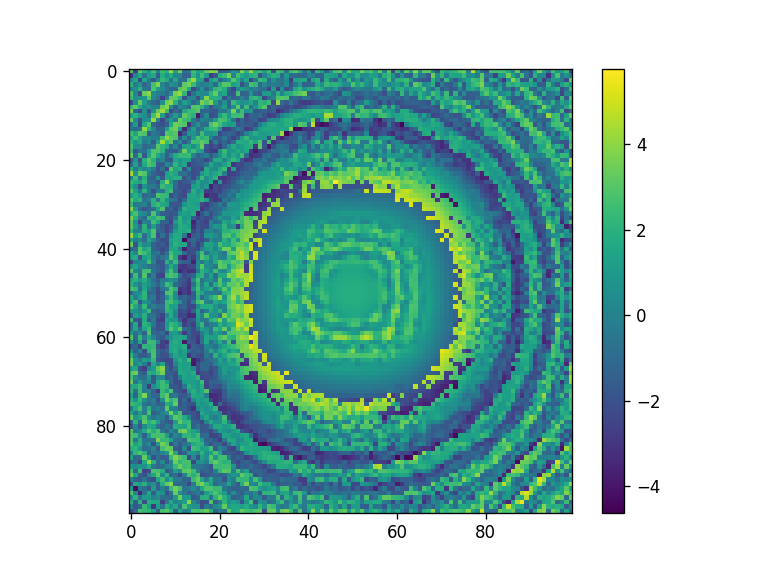

In [11]:
#optimize using the optimizer module  and Bluestein propagation (default) 
# the initial guess is the randimly initialized matrix 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-4)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()


Elapsed: 0:00:00.015930
Elapsed: 0:00:00.014935


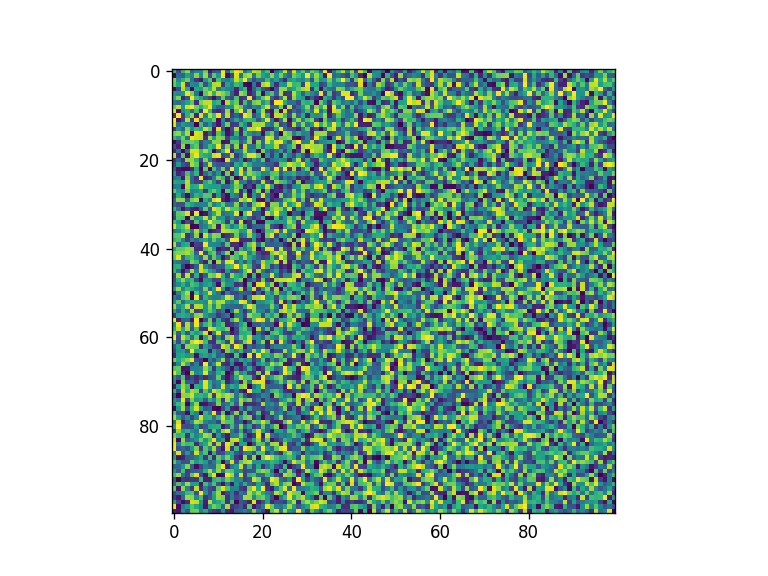

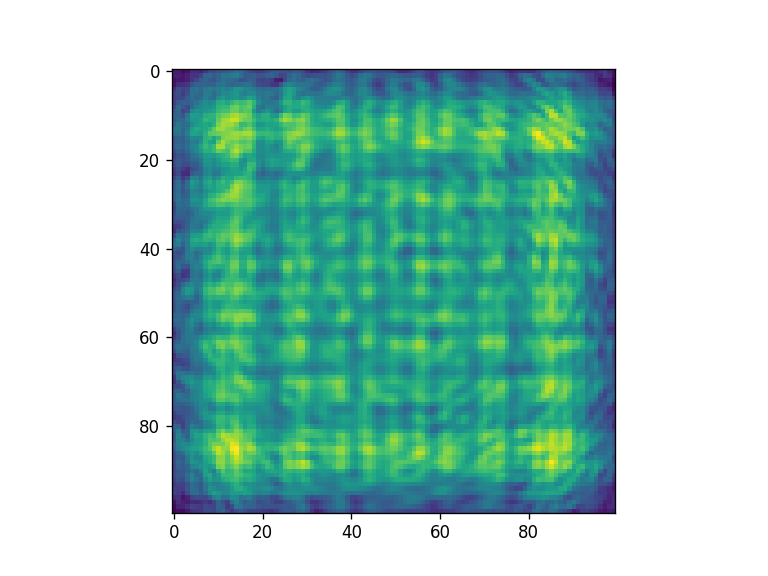

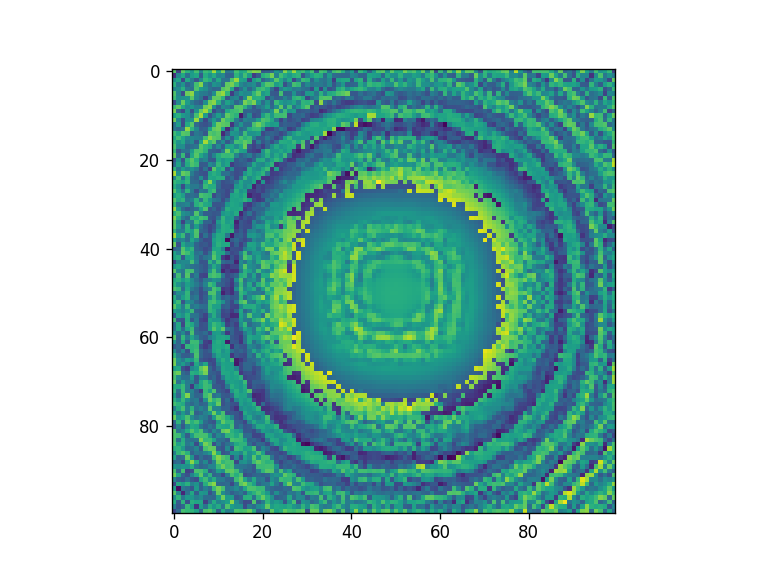

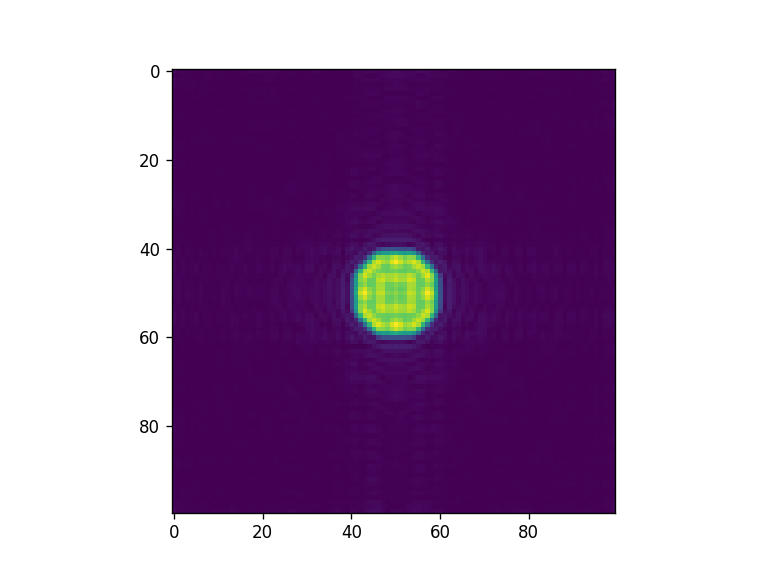

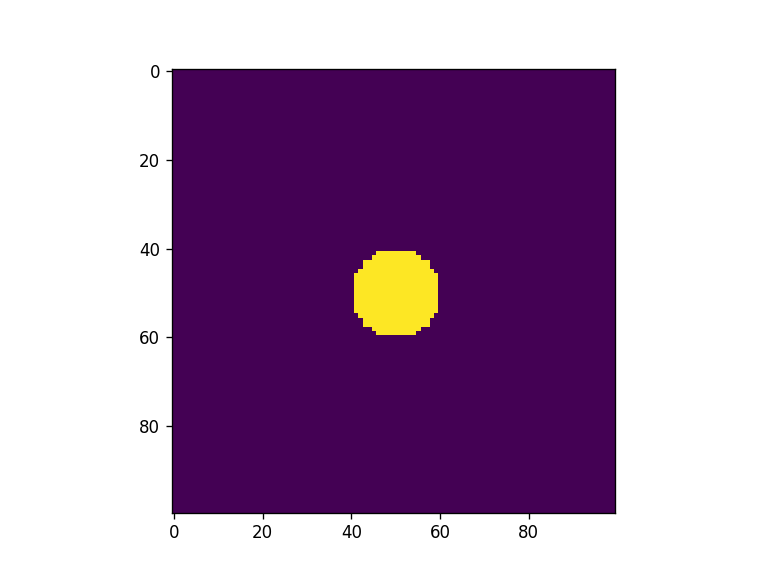

In [12]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [13]:
def FOM2(x, mask, screen, wavelength, mat, propag="bluestein"): 
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength, propagation_method=propag ))
    
    diff = np.abs(prop_x/prop_x[int(len(screen.x)/2), int(len(screen.y)/2)] - mat/np.max(mat))**2
     
    #print(diff.shape)
    res = np.log(np.sum(diff))
    #print(res)
    
    return res

In [14]:
## Optimization with ASM 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "ASM"], verbose = 1, ftol=1e-6)

C:\Users\jcunha377\AppData\Roaming\Python\Python311\site-packages\jax\_src\numpy\lax_numpy.py:148: UserWarning: Explicitly requested dtype complex128 requested in asarray is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


Elapsed: 0:00:02.734003
Elapsed: 0:00:00.979203
Elapsed: 0:00:00.035843
Elapsed: 0:00:00.071189
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.028376
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.073676
Elapsed: 0:00:00.031362
Elapsed: 0:00:00.102053
Elapsed: 0:00:00.040822
Elapsed: 0:00:00.043808
Elapsed: 0:00:00.081144
Elapsed: 0:00:00.029867
Elapsed: 0:00:00.073179
Elapsed: 0:00:00.029371
Elapsed: 0:00:00.083135
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.070192
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.072682
Elapsed: 0:00:00.027380
Elapsed: 0:00:00.069197
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.068699
Elapsed: 0:00:00.036340
Elapsed: 0:00:00.094585
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.071687
Elapsed: 0:00:00.029372
Elapsed: 0:00:00.084628
Elapsed: 0:00:00.035345
Elapsed: 0:00:00.086620
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.073179
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.073671
Elapsed: 0:00:00.028874
Elapsed: 0:00:00.078157
Elapsed: 0:00:00

Elapsed: 0:00:00.034352
Elapsed: 0:00:00.028374


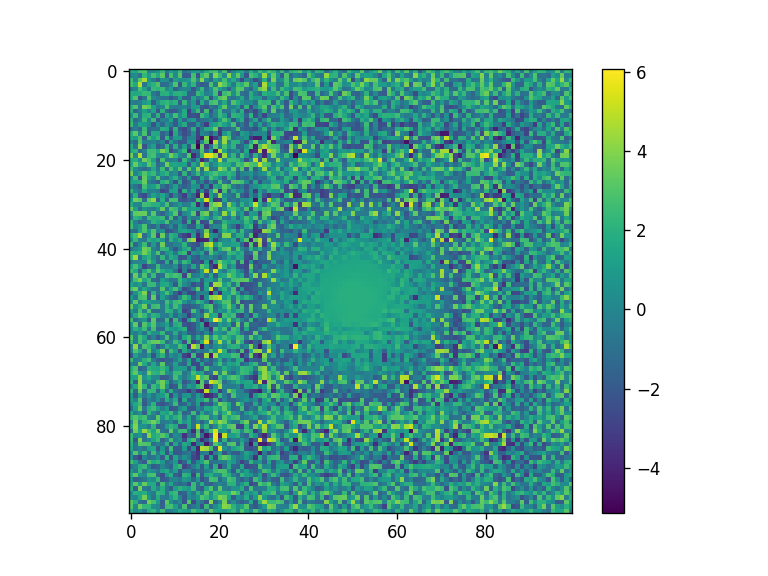

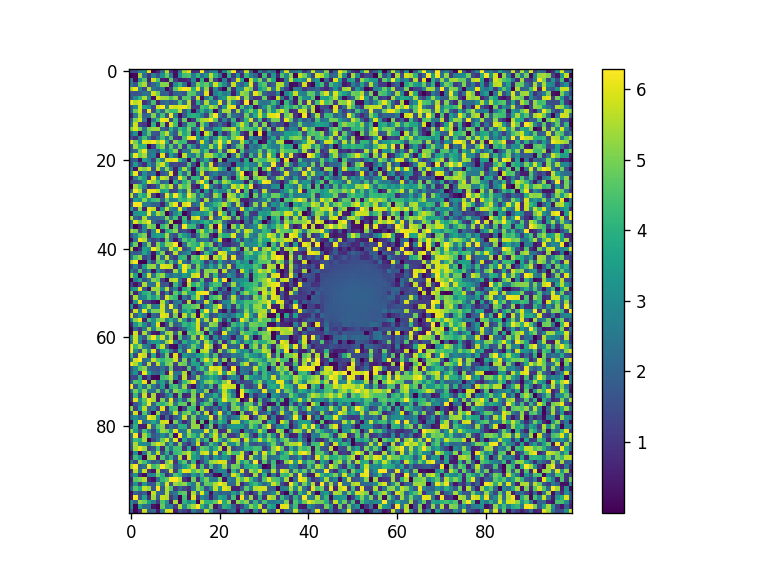

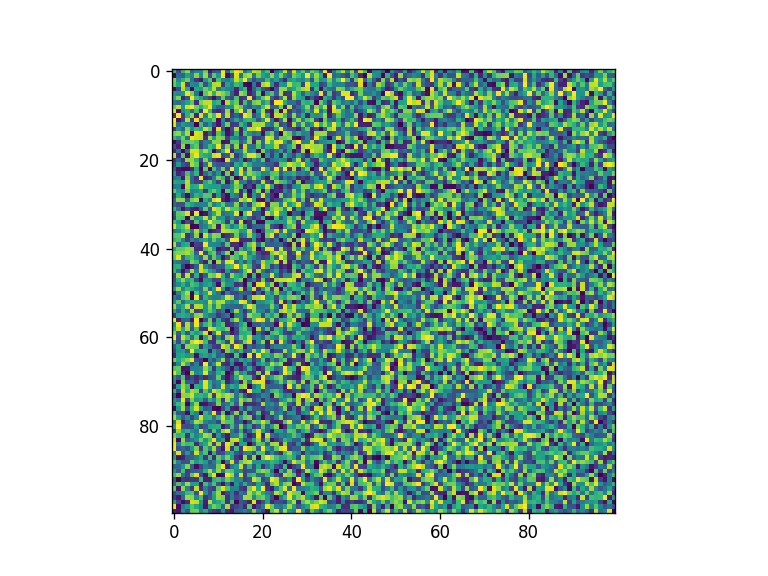

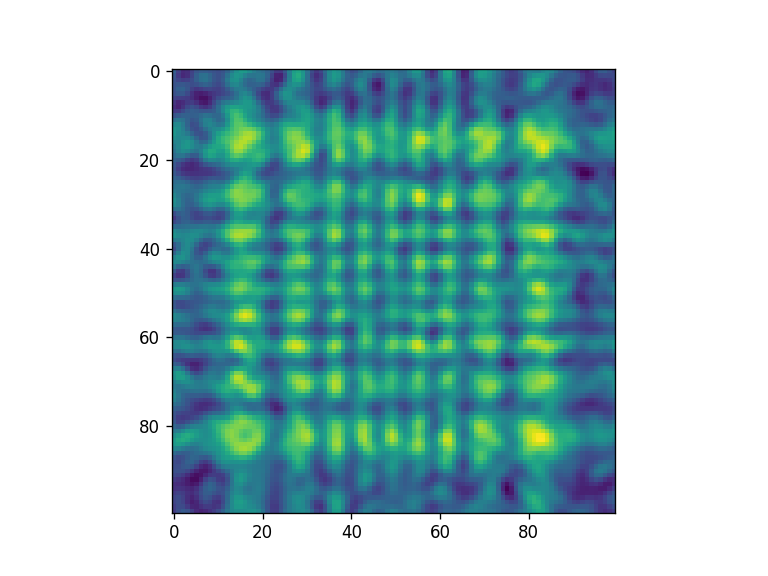

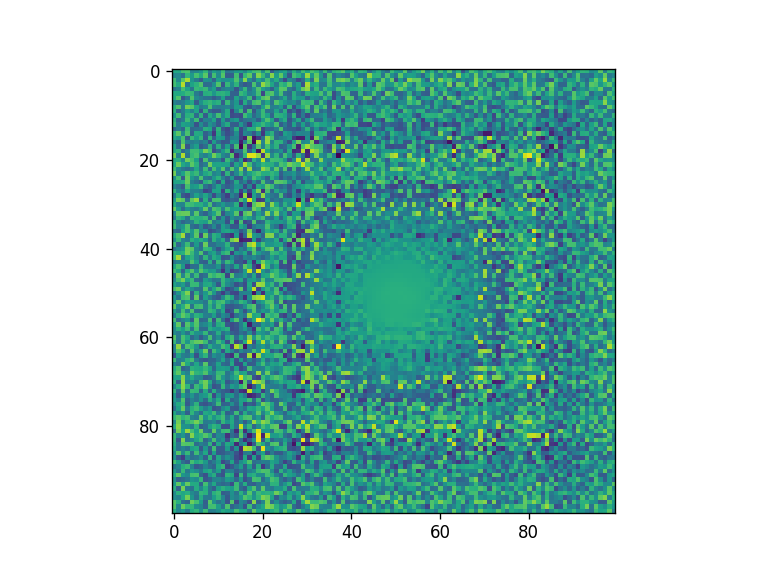

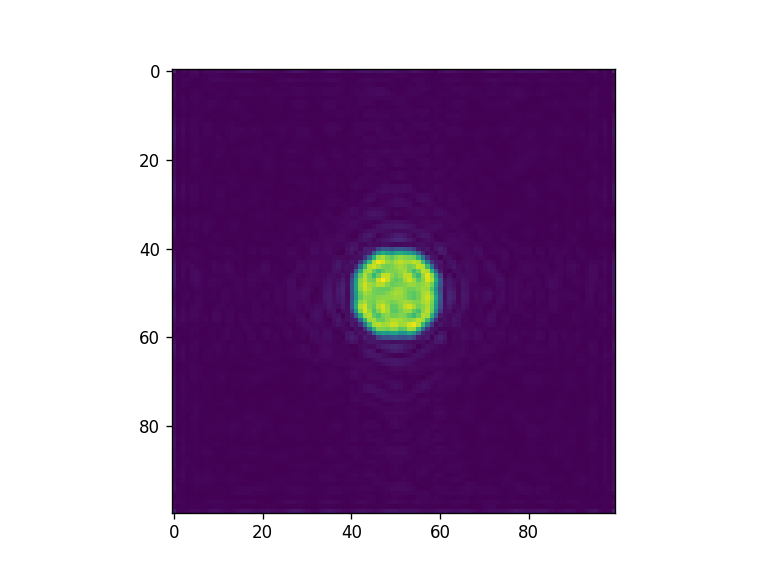

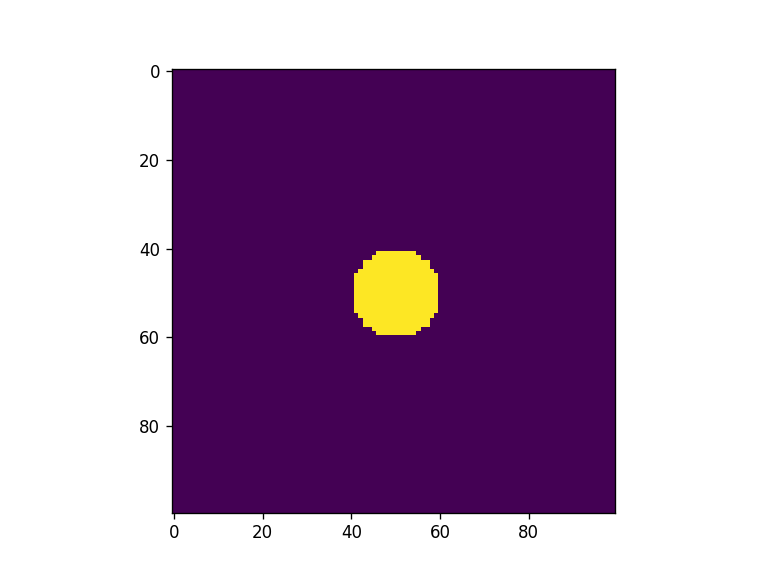

In [15]:
x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar%(2*np.pi)) 
plt.colorbar()

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength, propagation_method="ASM") ) )

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


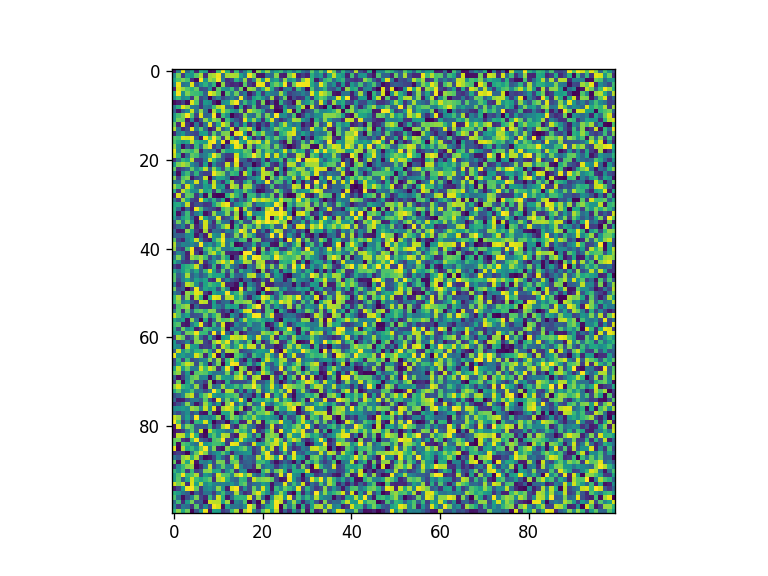

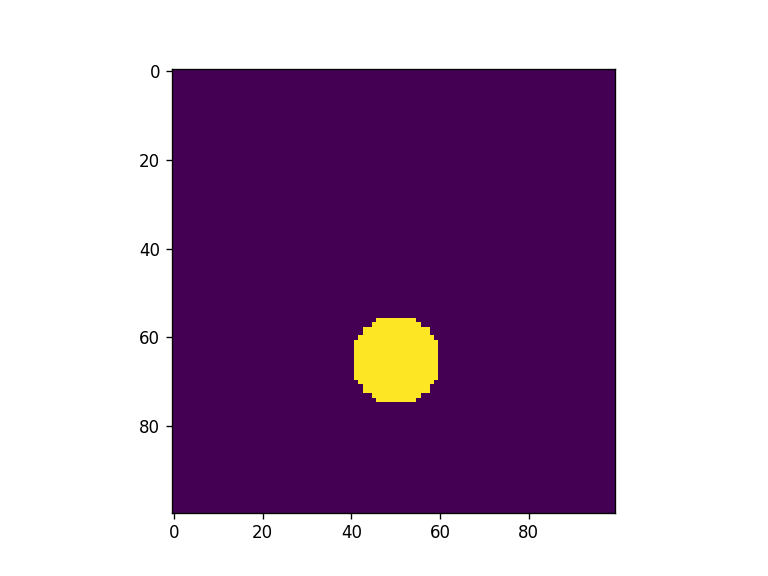

In [16]:
# re-define the Initial guess and target 
x_pixel, y_pixel = 100, 100

x0 = np.random.rand(x_pixel, y_pixel)
#x0 = np.ones((x_pixel, y_pixel))
x0_flatten = x0.flatten()

xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2- 0)**2 + (YY-y_pixel/2-15)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()

fig = plt.figure() 
plt.imshow(x0)


fig = plt.figure() 
plt.imshow(matrix)

Elapsed: 0:00:00.024393
Elapsed: 0:00:00.045301
Elapsed: 0:00:00.019414
Elapsed: 0:00:00.045301
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.054760
Elapsed: 0:00:00.021405
Elapsed: 0:00:00.044804
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.044804
Elapsed: 0:00:00.018420
Elapsed: 0:00:00.043310
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.048289
Elapsed: 0:00:00.030368
Elapsed: 0:00:00.020909
Elapsed: 0:00:00.055755
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.049284
Elapsed: 0:00:00.024891
Elapsed: 0:00:00.024891
Elapsed: 0:00:00.055258
Elapsed: 0:00:00.018418
Elapsed: 0:00:00.050280
Elapsed: 0:00:00.024393
Elapsed: 0:00:00.057248
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.017922
Elapsed: 0:00:00.046297
Elapsed: 0:00:00.022900
Elapsed: 0:00:00.057746
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.059240
Elapsed: 0:00:00.023398
Elapsed: 0:00:00.057249
Elapsed: 0:00:00.023397
Elapsed: 0:00:00.058742
Elapsed: 0:00:00.025389
Elapsed: 0:00:00.049285
Elapsed: 0:00:00.023894
Elapsed: 0:00:00

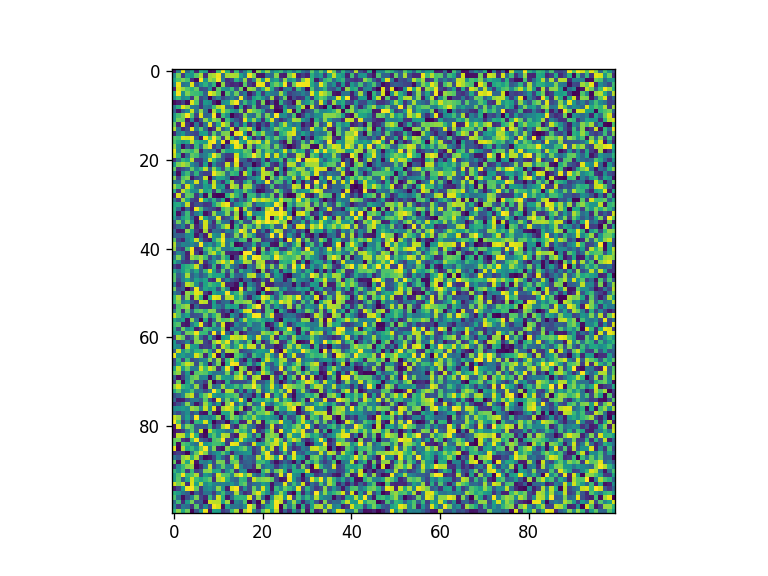

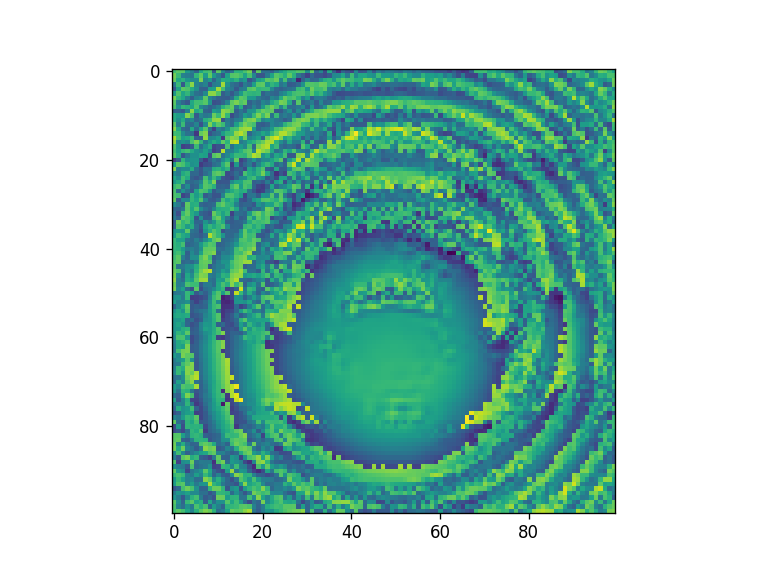

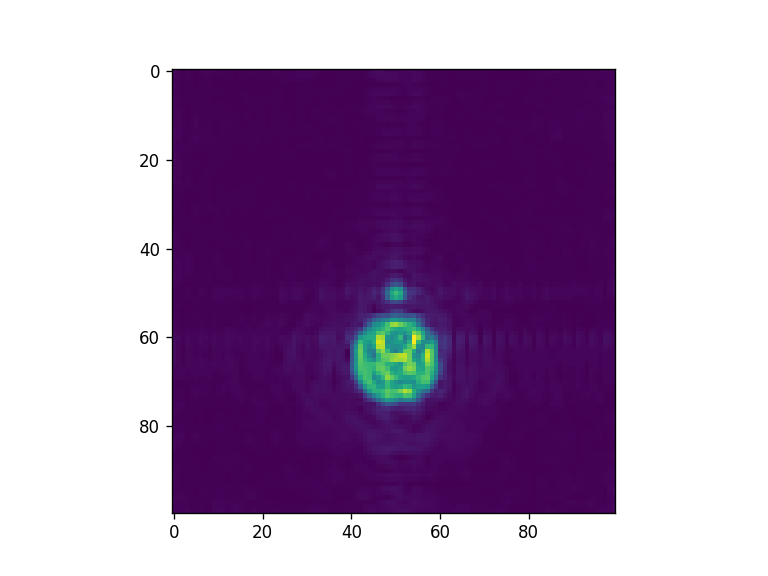

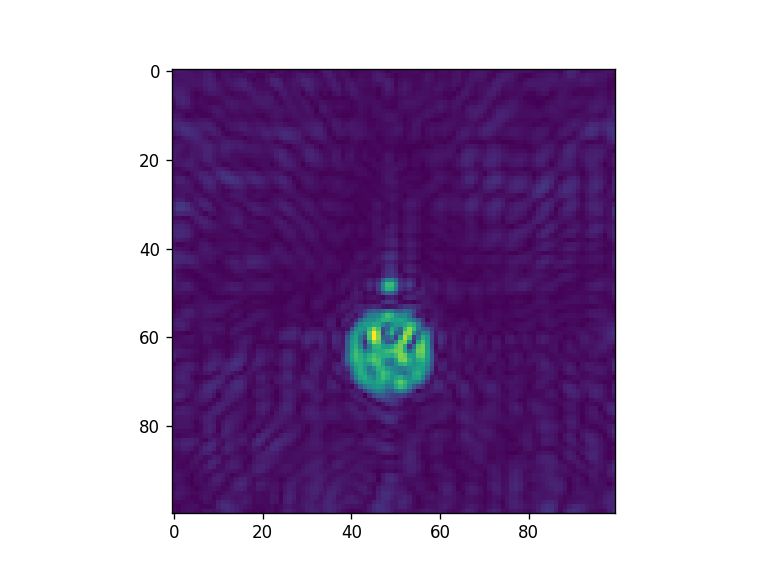

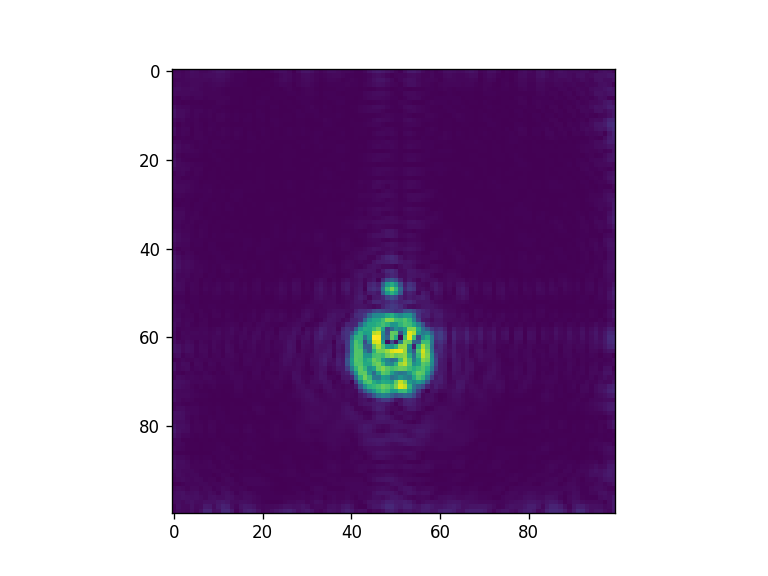

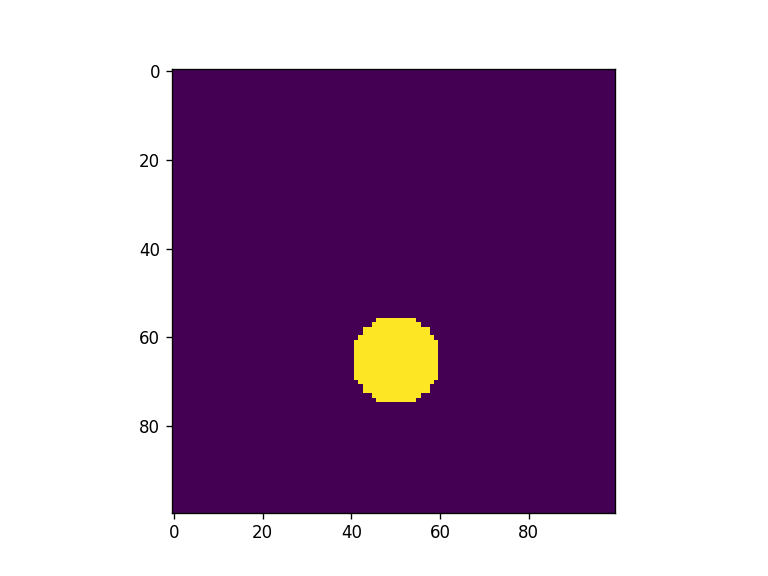

In [17]:
#Optimization with SASM 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "SASM"], verbose = 1, ftol=1e-3)

x = solution.x

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="SASM") ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )
fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


In [18]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, ], verbose = 1, ftol=1e-3)

x = solution.x

Elapsed: 0:00:00.015931
Elapsed: 0:00:00.041321
Elapsed: 0:00:00.015929
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.017423
Elapsed: 0:00:00.041818
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.041816
Elapsed: 0:00:00.017424
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.053764
Elapsed: 0:00:00.015431
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.040822
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.040324
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.014431
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.013939
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.016428
Elapsed: 0:00:00.039826
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.076663
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.077659
Elapsed: 0:00:00.018918
Elapsed: 0:00:00.042315
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.013938
Elapsed: 0:00:00.039326
Elapsed: 0:00:00.014934
Elapsed: 0:00:00

Elapsed: 0:00:00.018917
Elapsed: 0:00:00.028378
Elapsed: 0:00:00.014934


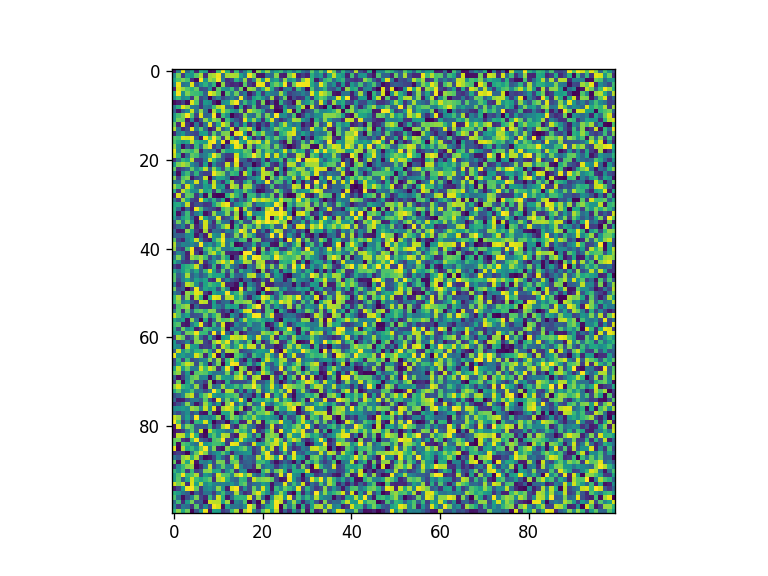

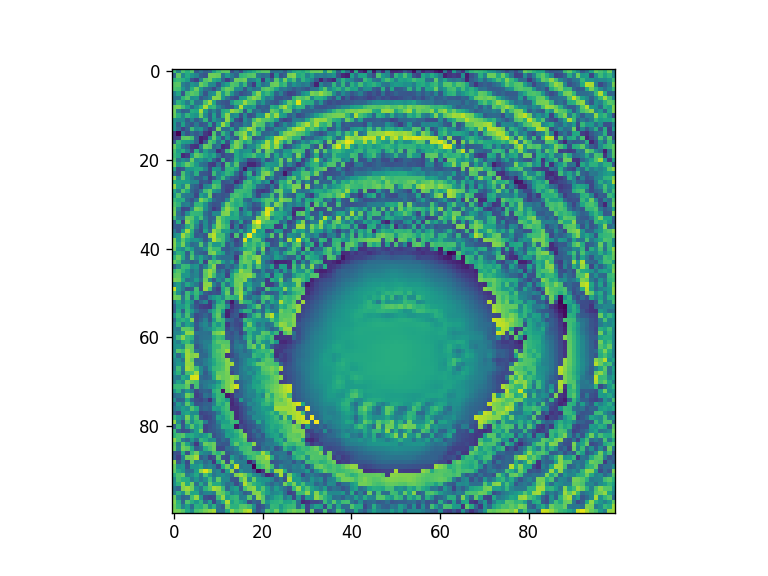

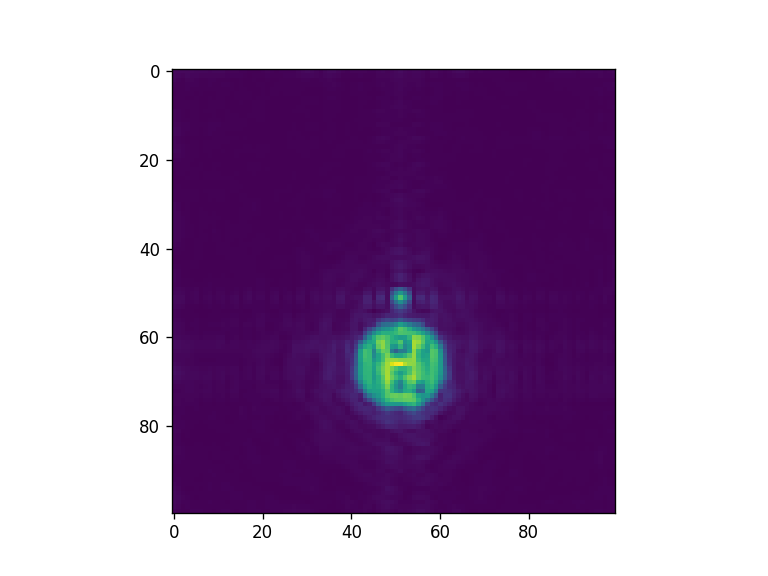

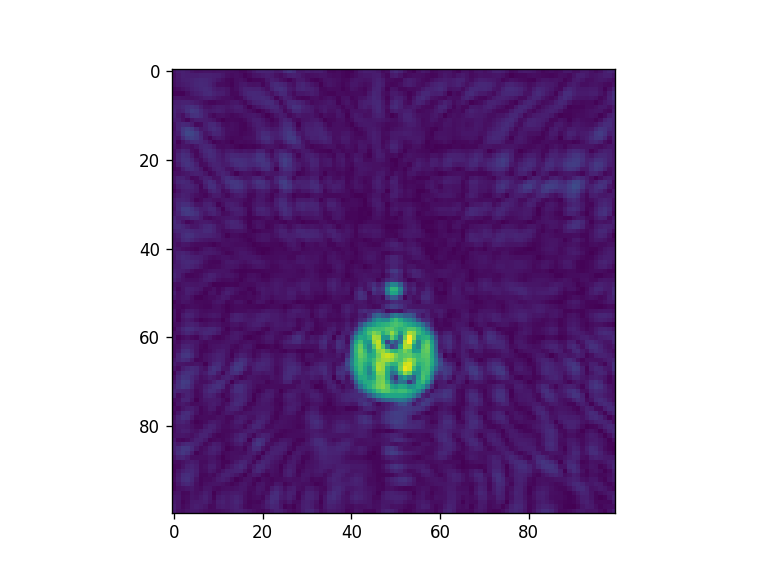

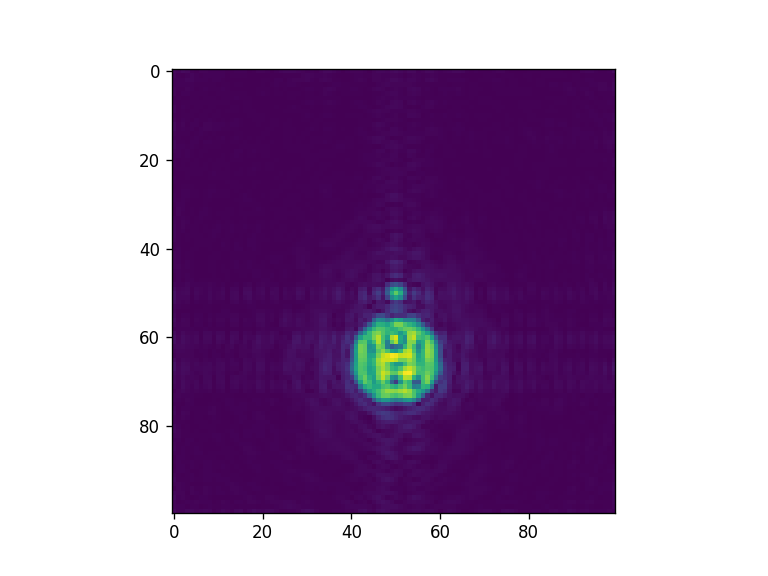

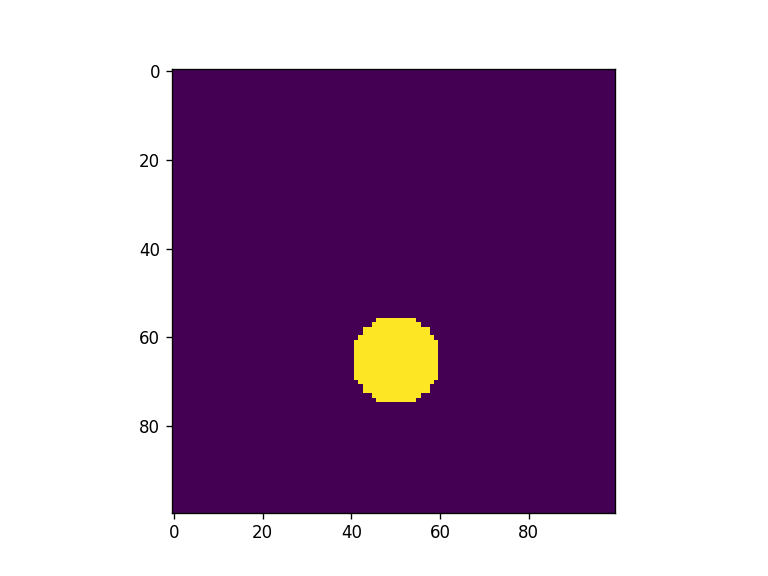

In [19]:

fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
xar3 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar3) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="SASM") ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength, propagation_method="ASM") ) )
fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) ) )


fig = plt.figure() 
plt.imshow(np.reshape(matrix, (x_pixel, y_pixel)) )


Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.015928
Elapsed: 0:00:00.041318
Elapsed: 0:00:00.020907
Elapsed: 0:00:00.056751
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.056253
Elapsed: 0:00:00.018420
Elapsed: 0:00:00.051772
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040324
Elapsed: 0:00:00.014934
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.015924
Elapsed: 0:00:00.014436
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.014437
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.015433
Elapsed: 0:00:00.042813
Elapsed: 0:00:00.015930
Elapsed: 0:00:00.043310
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.014938
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.040323
Elapsed: 0:00:00.015433
Elapsed: 0:00:00.041319
Elapsed: 0:00:00.015432
Elapsed: 0:00:00.040821
Elapsed: 0:00:00.015432
Elapsed: 0:00:00

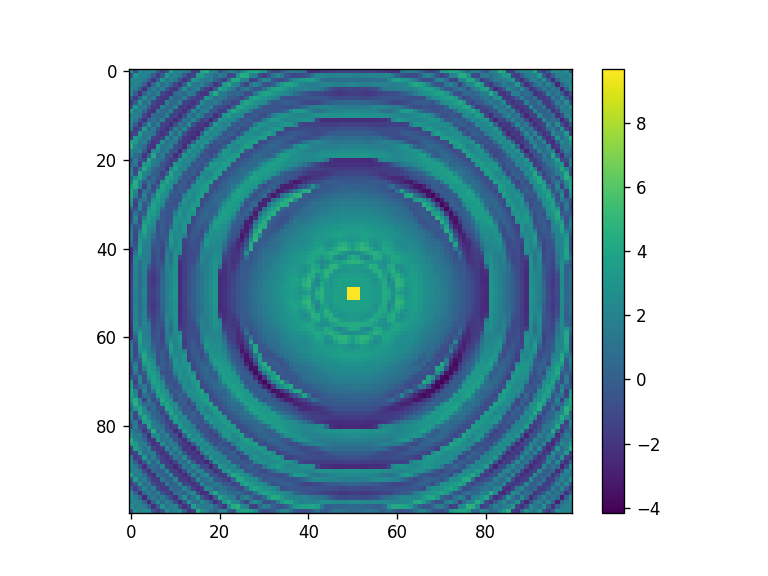

In [20]:
### Testing constant value initial guess 

#Initial guess
x_pixel, y_pixel = 100, 100


x0 = np.ones((x_pixel,y_pixel))
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    
matrix = np.zeros((x_pixel, y_pixel))
matrix[np.where(((XX-x_pixel/2)**2 + (YY-y_pixel/2)**2) < 10**2)] = 1 

matrix_flat = matrix.flatten()


solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=[mask2, screen, wavelength, matrix, "bluestein"], verbose=1, ftol=1e-3)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015929
Elapsed: 0:00:00.015434


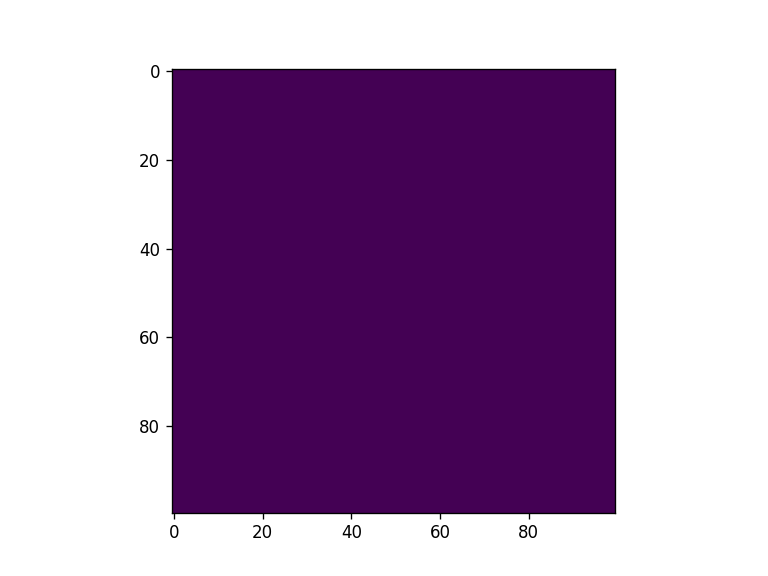

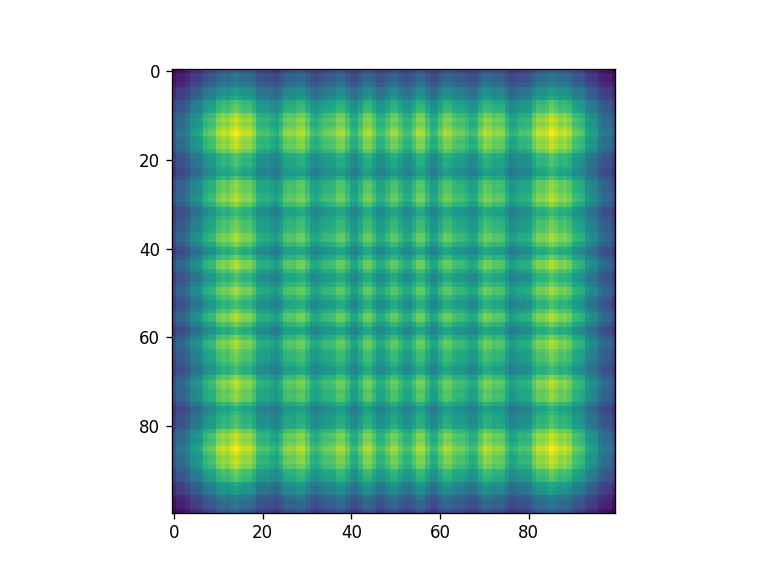

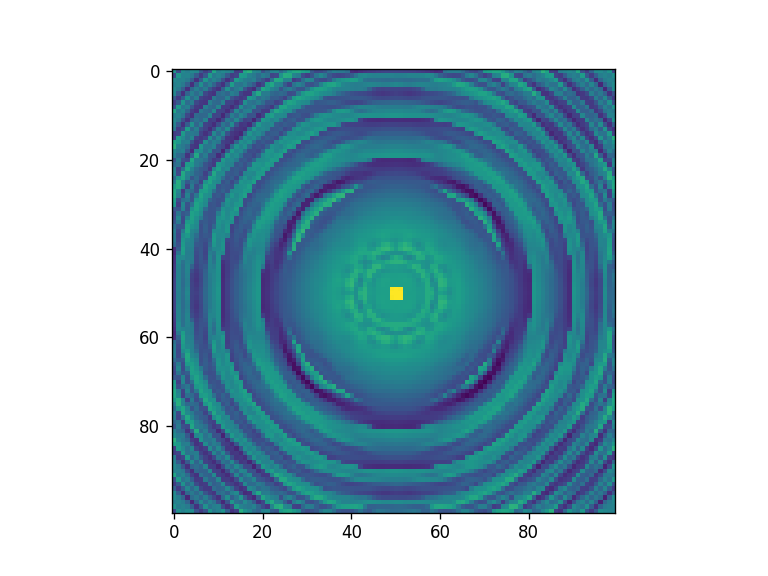

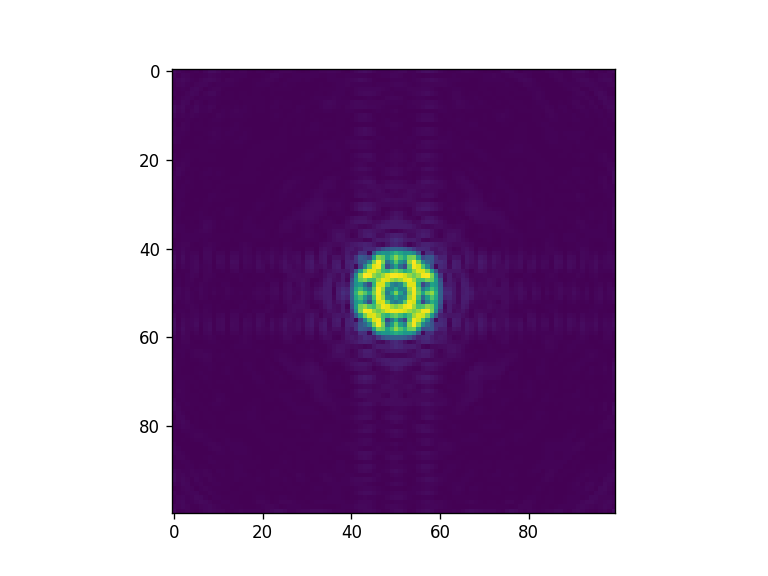

In [21]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


Elapsed: 0:00:00.029866
Elapsed: 0:00:00.071188
Elapsed: 0:00:00.030367
Elapsed: 0:00:00.097074
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.081144
Elapsed: 0:00:00.035843
Elapsed: 0:00:00.086121
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.028872
Elapsed: 0:00:00.073179
Elapsed: 0:00:00.028892
Elapsed: 0:00:00.072183
Elapsed: 0:00:00.029371
Elapsed: 0:00:00.074175
Elapsed: 0:00:00.029372
Elapsed: 0:00:00.069693
Elapsed: 0:00:00.029372
Elapsed: 0:00:00.069694
Elapsed: 0:00:00.028375
Elapsed: 0:00:00.078157
Elapsed: 0:00:00.038830
Elapsed: 0:00:00.101056
Elapsed: 0:00:00.039328
Elapsed: 0:00:00.103046
Elapsed: 0:00:00.038829
Elapsed: 0:00:00.094087
Elapsed: 0:00:00.027878
Elapsed: 0:00:00.069196
Elapsed: 0:00:00.030367
Elapsed: 0:00:00.074176
Elapsed: 0:00:00.037834
Elapsed: 0:00:00.100061
Elapsed: 0:00:00.028873
Elapsed: 0:00:00.085624
Elapsed: 0:00:00.035841
Elapsed: 0:00:00.093590
Elapsed: 0:00:00.036341
Elapsed: 0:00:00.073179
Elapsed: 0:00:00.029869
Elapsed: 0:00:00.070192
Elapsed: 0:00:00

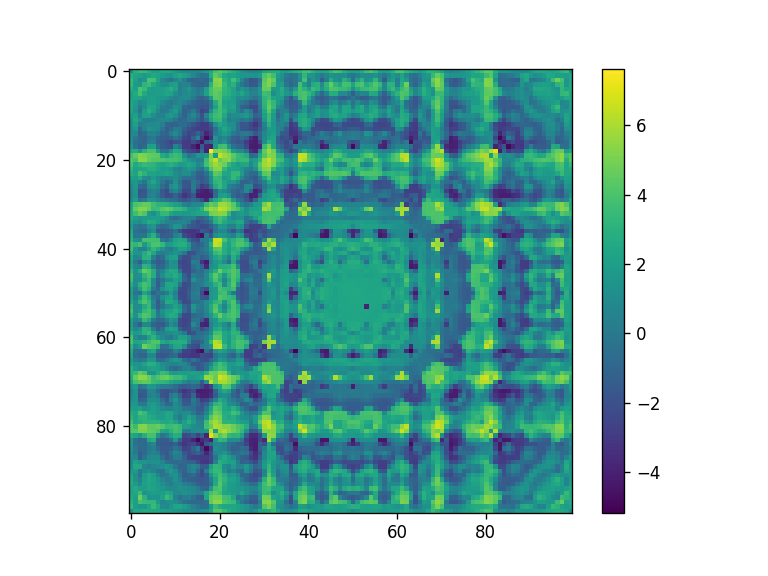

In [22]:
solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength,matrix, "ASM"), optimizer_method="dogbox", verbose=0, ftol=1e-5)

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.026384
Elapsed: 0:00:00.014935
Elapsed: 0:00:00.043806


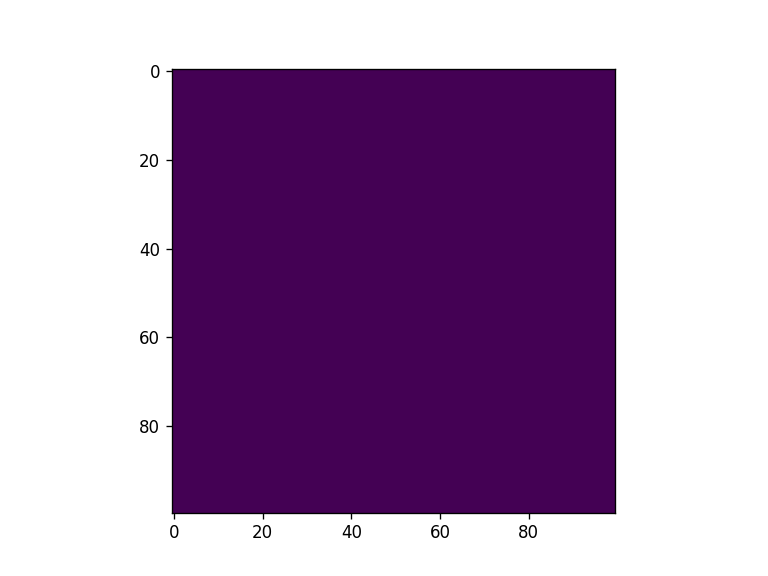

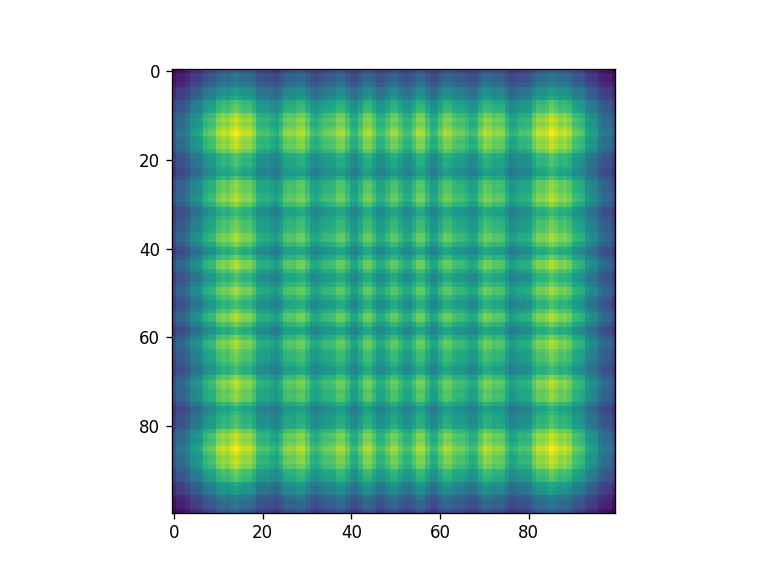

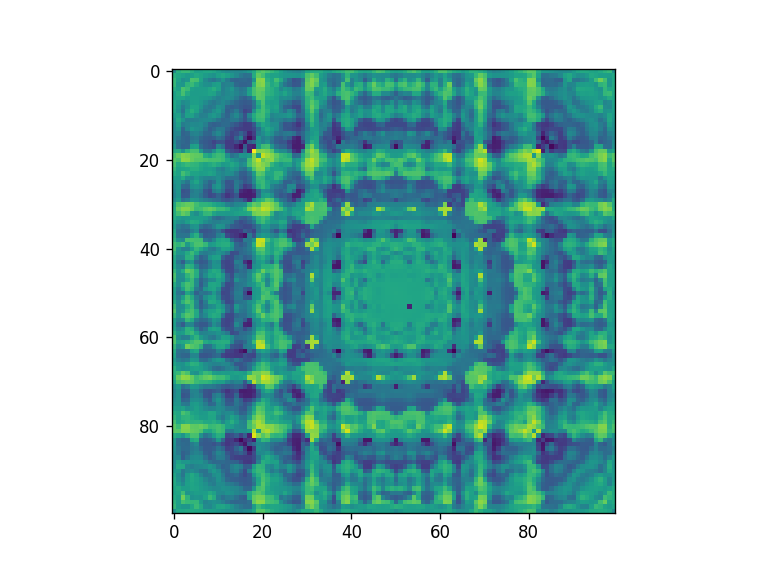

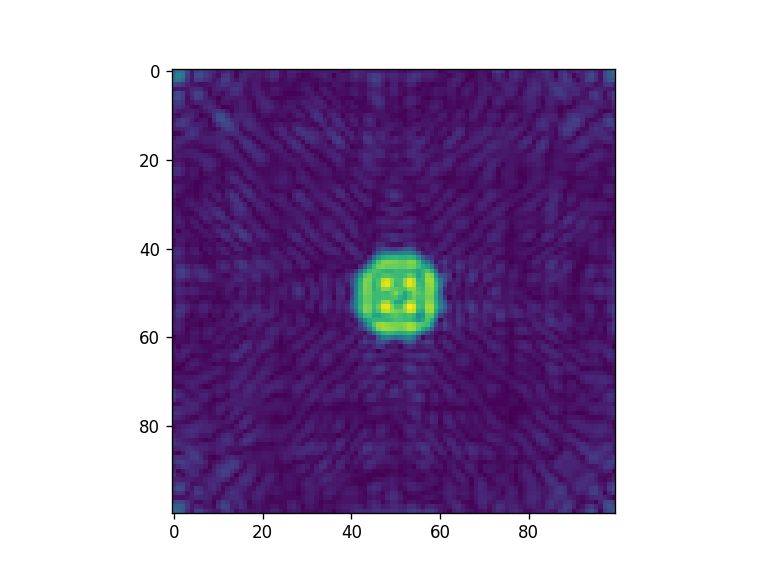

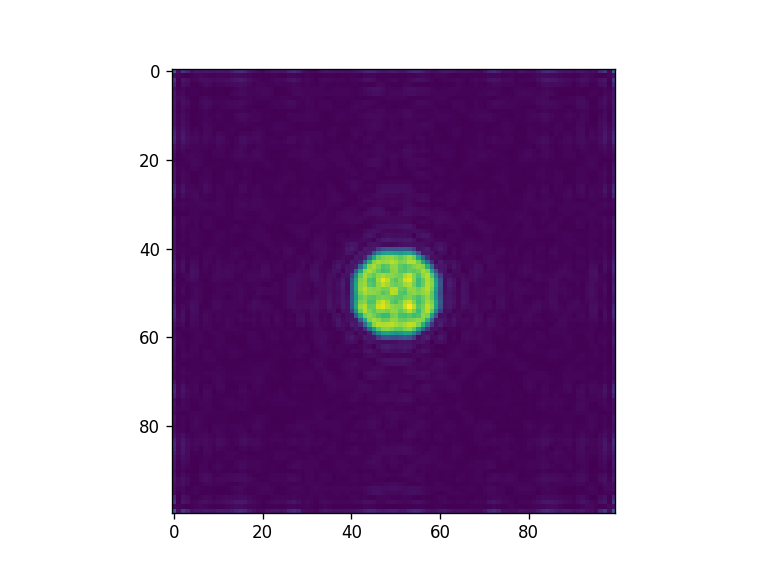

In [23]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength, propagation_method="ASM") ) )


Elapsed: 0:00:00.019415
Elapsed: 0:00:00.043808
Elapsed: 0:00:00.023897
Elapsed: 0:00:00.066188
Elapsed: 0:00:00.019912
Elapsed: 0:00:00.045301
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.067205
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.044797
Elapsed: 0:00:00.018419
Elapsed: 0:00:00.043808
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.042812
Elapsed: 0:00:00.017921
Elapsed: 0:00:00.044305
Elapsed: 0:00:00.018917
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.018916
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.044803
Elapsed: 0:00:00.024891
Elapsed: 0:00:00.056751
Elapsed: 0:00:00.019912
Elapsed: 0:00:00.045803
Elapsed: 0:00:00.025388
Elapsed: 0:00:00.058245
Elapsed: 0:00:00.019418
Elapsed: 0:00:00.058244
Elapsed: 0:00:00.025389
Elapsed: 0:00:00.057748
Elapsed: 0:00:00.021406
Elapsed: 0:00:00.056253
Elapsed: 0:00:00.019414
Elapsed: 0:00:00.056751
Elapsed: 0:00:00.023398
Elapsed: 0:00:00.057747
Elapsed: 0:00:00.019415
Elapsed: 0:00:00.045300
Elapsed: 0:00:00.017921
Elapsed: 0:00:00

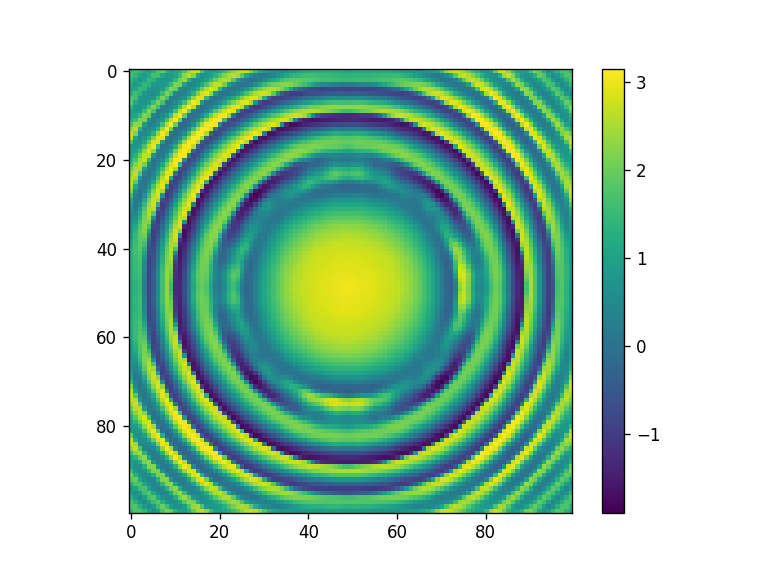

In [24]:
## Optimization with bounds 

solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen, wavelength, matrix, "SASM"), optimizer_method="dogbox", bounds =(-np.pi, np.pi), ftol = 1e-12 )

x = solution.x

fig = plt.figure() 
xar = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.015433
Elapsed: 0:00:00.014935


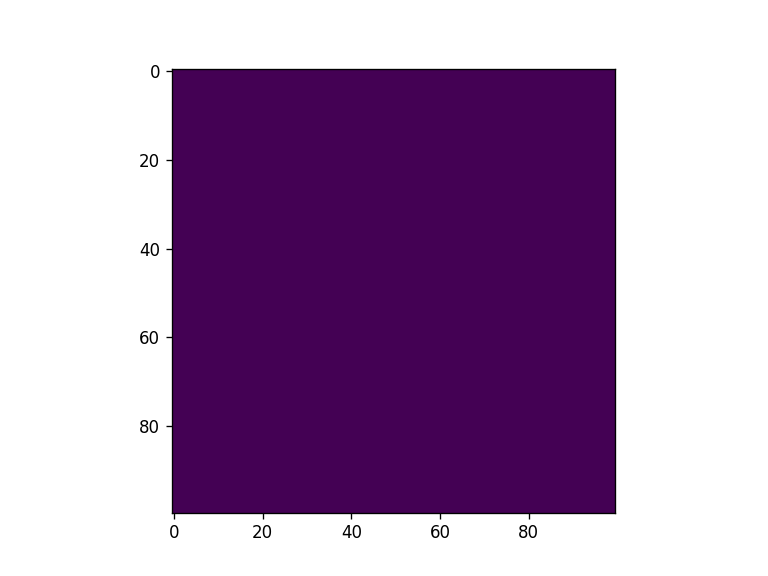

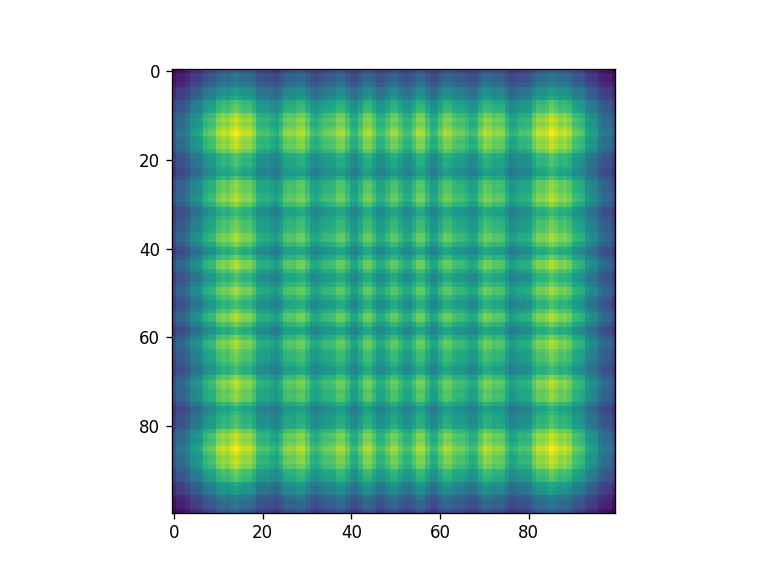

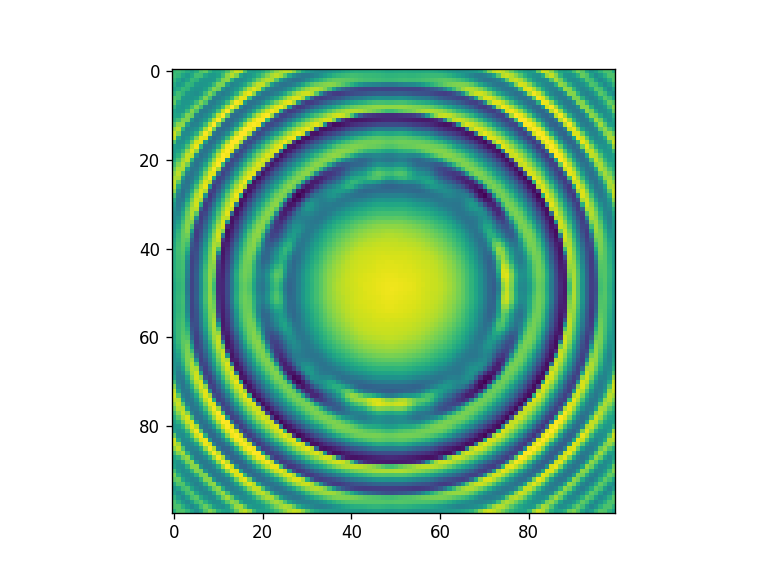

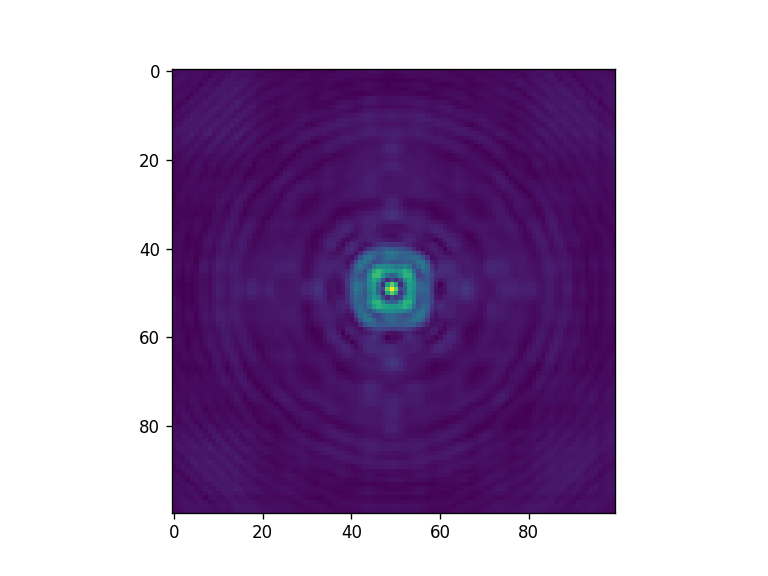

In [25]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) ) )

fig = plt.figure() 
xar2 = np.reshape(x, (x_pixel, y_pixel))
plt.imshow(xar2) 

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar, mask2, screen, wavelength) ) )


In [26]:
#Uncomment to try any of these global optimization methods 

##bounds = [(-np.pi, np.pi)]*len(x0_flatten)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen,wavelength),  optimizer_method="dual_annealing", tol=1 , minimizer_kwargs={"args":(mask2, screen, wavelength), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="basinhopping", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

##solution = moe.optimizer.optimize(FOM2, x0_flatten, args1=(mask2, screen),  optimizer_method="differential_evolution", tol=1 ,minimizer_kwargs={"args":(mask2, screen), "tol": 1 },  bounds = bounds)

## Hologram creation via inverse design

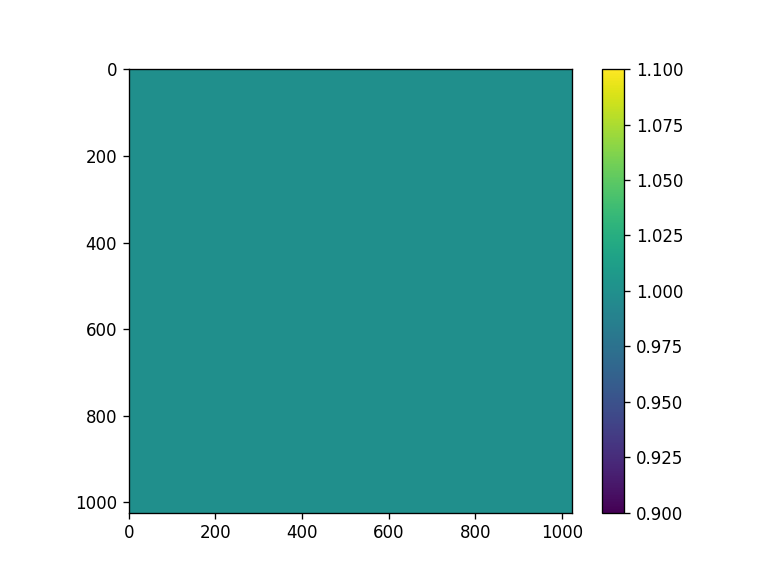

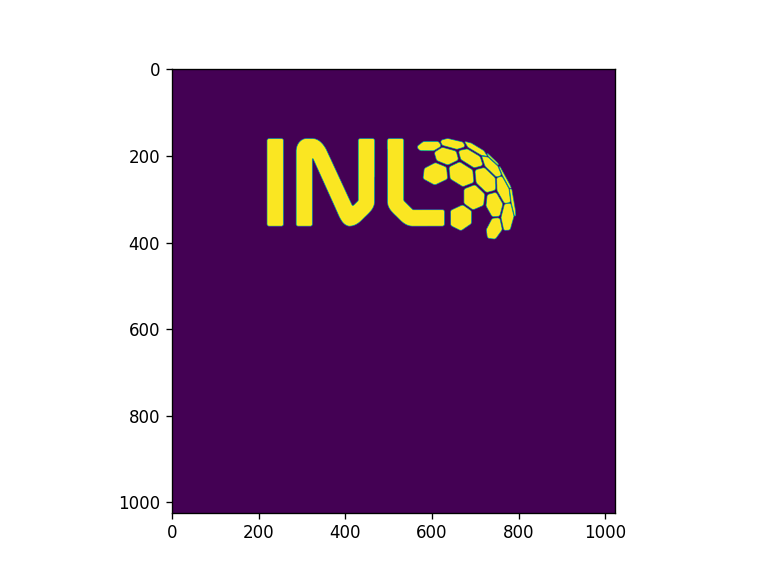

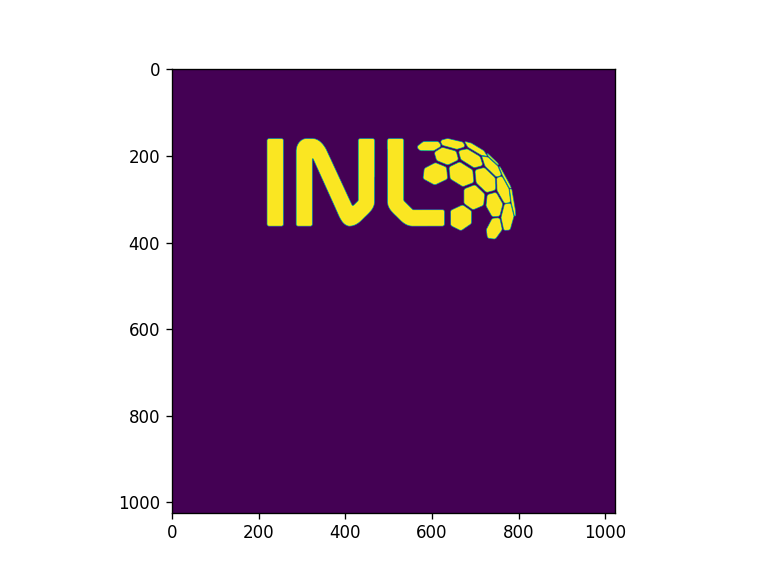

In [27]:
#Using GS first 

#Initial guess
x_pixel, y_pixel = 100, 100
matrix = plt.imread("target.png")

x_pixel, y_pixel = np.shape(matrix)
matrix_flat = matrix.flatten()

x0 = np.random.rand(x_pixel, y_pixel) 
x0 = np.ones((x_pixel,y_pixel))
#x0 = 
x0_flatten = x0.flatten()


xi = np.arange(x_pixel)
yi = np.arange(y_pixel)
XX, YY = np.meshgrid(xi,yi)
    

fig = plt.figure() 
plt.imshow(x0)
plt.colorbar()


fig = plt.figure() 
plt.imshow(matrix)

fig = plt.figure() 
plt.imshow(np.reshape(matrix_flat, (x_pixel, y_pixel)))

Progress: [####################] 100.0%
[Gerchberg Saxton Algorithm]
Elapsed: 0:01:12.853786


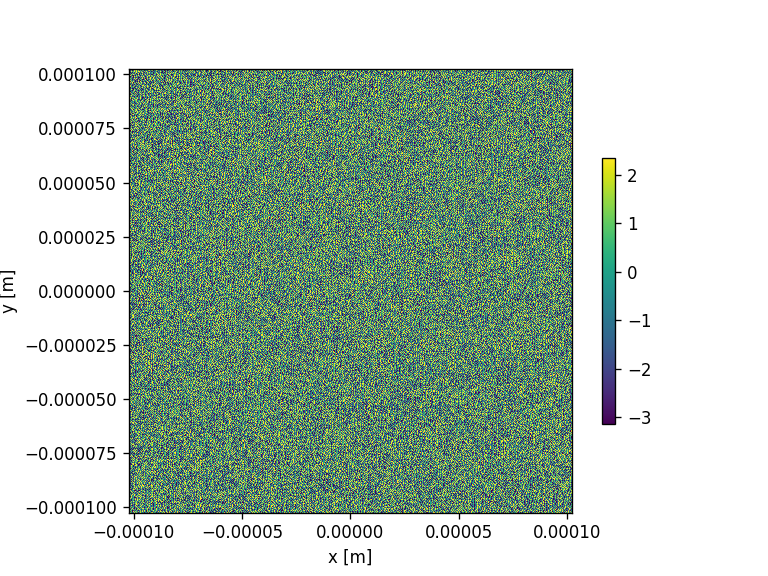

In [28]:
# Multilevel phase hologram
levels = 8

iterations = 100

levels = moe.utils.create_levels(-np.pi, np.pi, levels,)
phase_mask, errors = moe.holograms.algorithm_Gerchberg_Saxton(matrix, iterations=iterations, levels=levels)

phase_mask = moe.holograms.correct_mask_shift(phase_mask)
mask = moe.generate.create_aperture_from_array(phase_mask, pixel_size=(0.2*micro, 0.2*micro), center=True, )


# Discretize to same levels as original
mask.discretize(levels)
moe.plotting.plot_aperture(mask)

In [29]:
mask.aperture

array([[-0.78539816,  0.        ,  0.        , ..., -3.14159265,
        -3.14159265, -1.57079633],
       [-1.57079633, -0.78539816, -2.35619449, ...,  1.57079633,
         1.57079633, -2.35619449],
       [-2.35619449, -2.35619449,  2.35619449, ...,  0.        ,
        -0.78539816, -2.35619449],
       ...,
       [-3.14159265, -2.35619449,  0.        , ...,  0.78539816,
         0.78539816, -3.14159265],
       [ 1.57079633,  2.35619449, -1.57079633, ..., -0.78539816,
        -0.78539816,  1.57079633],
       [ 0.78539816,  1.57079633, -3.14159265, ..., -2.35619449,
        -2.35619449,  0.        ]])

Text(0.5, 1.0, 'Calculated far field intensity')

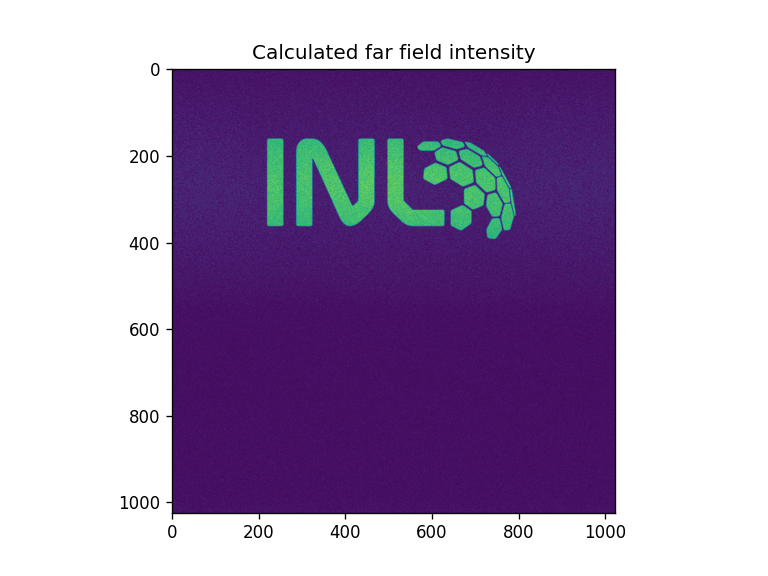

In [30]:
far_field = moe.holograms.calculate_phase_farfield(phase_mask)

plt.figure()
plt.imshow(far_field)
plt.title("Calculated far field intensity")

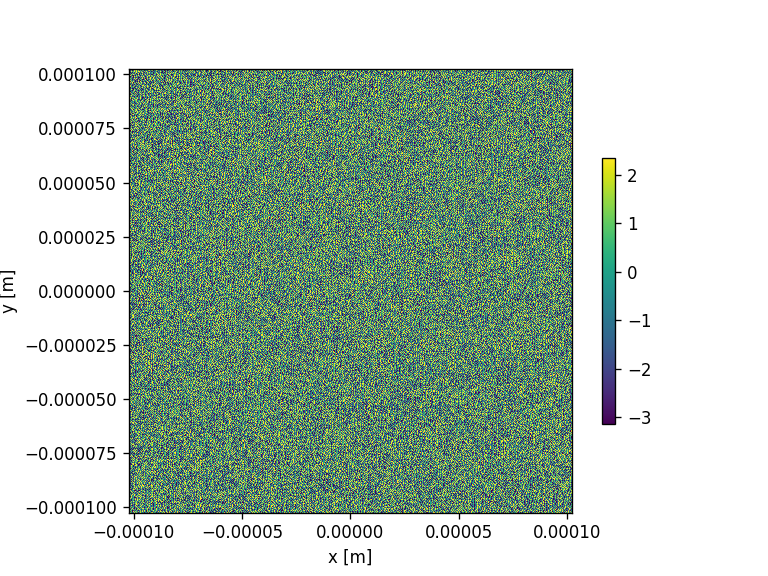

In [31]:
moe.plotting.plot_aperture(mask)

In [32]:
#Place holders for apertures 

#size of the rectangular mask 
aperture_width  = 50e-6 #m
aperture_height = 50e-6

pixsize = 1e-6 #m

wavelength = 500e-9 #m
focal_length = 200e-6

zmin = wavelength
zmax = 1.2* focal_length
nzs = 500

radius = aperture_width/2 

# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask1 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask1)


##############
###Fresnel mask with a truncated circular aperture 

# Create empty mask
aperture2 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)


# and truncate around radius
mask2 = moe.generate.fresnel_phase(aperture2, focal_length, wavelength, radius=radius)
#moe.plotting.plot_aperture(mask2)

# Discretize mask in number of levels
# Select exact position of contours  in phase
phase_vals = np.linspace(-np.pi, np.pi, 16)

mask2.discretize(np.array( phase_vals)[:] ) 
#moe.plotting.plot_aperture(mask2)

# Generate a uniform field
field = moe.field.create_empty_field_from_aperture(mask2)

field = moe.field.generate_uniform_field(field, E0=1)

# Modulates the field 
field = moe.field.modulate_field(field, amplitude_mask=None, phase_mask=mask2 )


# Create Aperture
aperture1 = moe.generate.create_empty_aperture(-aperture_width/2, aperture_width/2, x_pixel, -aperture_height/2, aperture_height/2, y_pixel)

# Populate Aperture with Fresnel mask 
mask2 = moe.generate.fresnel_phase(aperture1, focal_length, wavelength )

#moe.plotting.plot_aperture(mask2)

In [33]:
#Define Screen 

# define the wavelength used in the propagation
wavelength = 532*nano

# Define the screen size and create it

screen_width = 2.5
screen_height = 2.5
x_pixel = 1024
y_pixel = 1024


# Creates a screen in YZ plane with [-aperture_height/2, aperture_height/2] and [zmin, zmax] and 
ymin, ymax = -screen_height/2, screen_height/2
xmin, xmax = -screen_width/2, screen_width/2 

s=0.1

x = np.linspace(xmin*s, xmax*s, x_pixel)
y = np.linspace(ymin*s, ymax*s, y_pixel)
z = np.array([2*s])


screen = moe.field.Screen(x,y,z)

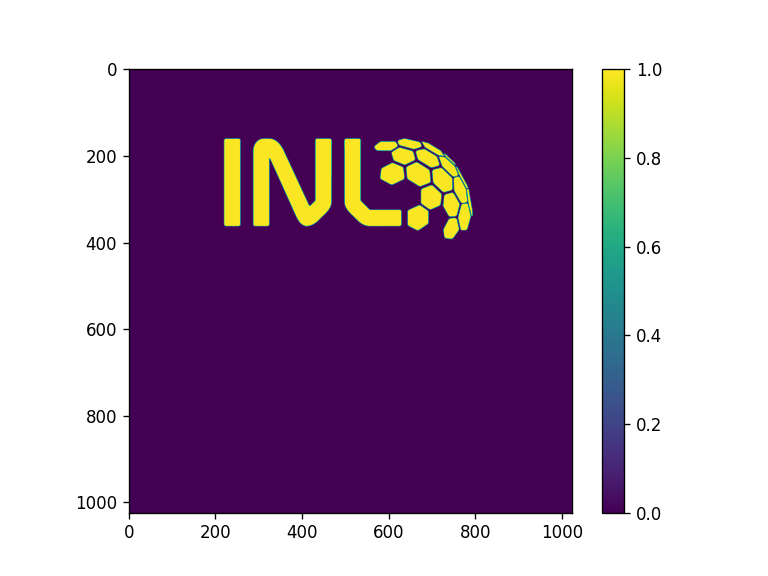

In [34]:

fig = plt.figure() 
plt.imshow(matrix)
plt.colorbar()

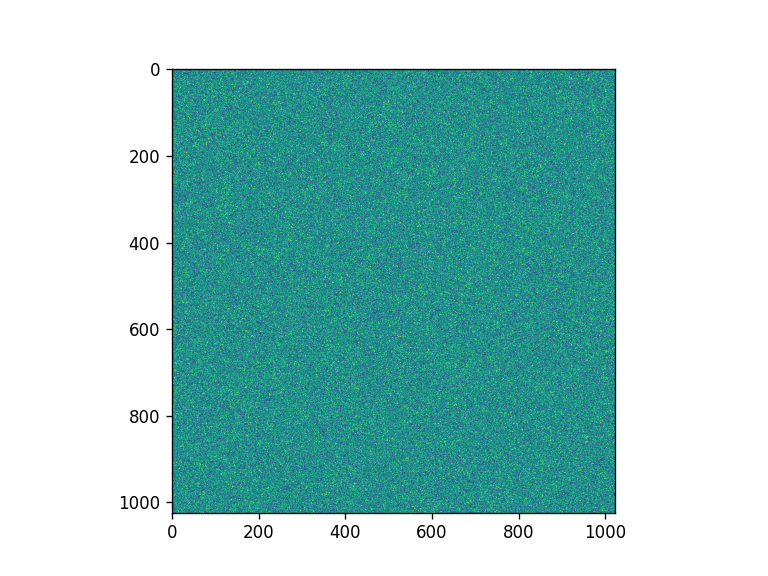

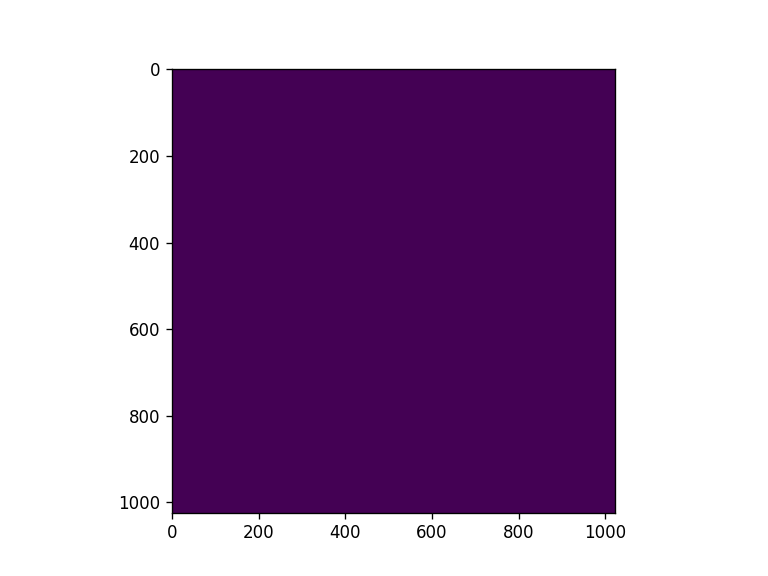

In [35]:
# generation of initial guesses, 

#random 
xrand = np.random.rand(x_pixel, y_pixel)

plt.figure() 
plt.imshow(xrand)

#constant 
xvalues = np.ones((x_pixel, y_pixel))

plt.figure()
plt.imshow(xvalues)
#plt.colorbar()

In [36]:
def FOM3(x, mask, screen, wavelength, mat, propag="bluestein", pad=2): 
    #print("Type of x:", type(x), "First element:", x[0])
    #print("Type of x:", type(mask))
    #print("Type of x:", type(screen), "First element:", x[0])
    #print("Type of x:", type(wavelength), "First element:", x[0])
    import jax.numpy as np 
    
    prop_x =  np.abs(moe.optimizer.propagate(np.reshape(x, (len(screen.x), len(screen.y))), mask, screen, wavelength,\
                                             propagation_method=propag, pad_factor=pad))**2
    
    #diff = np.abs(prop_x - mat/np.max(mat)*np.max(prop_x))**2
    diff = np.abs(prop_x/np.max(prop_x) - mat/np.max(mat))**2
     
    #print(diff.shape)
    #jax.debug.print(str(np.max(diff))+"  "+str(np.max(prop_x))+" "+str(np.min(prop_x)) )
    
    #res = (np.sqrt(np.sum(diff)) )
    res = np.sum(diff)
    #print(res)

    
    #jax.debug.print(f"{res}")
    
    return res

Elapsed: 0:00:02.050501
Elapsed: 0:00:01.412796
Elapsed: 0:00:00.591408
Elapsed: 0:00:00.789038
Elapsed: 0:00:00.582443
Elapsed: 0:00:00.869188
Elapsed: 0:00:00.611317
Elapsed: 0:00:00.781569
Elapsed: 0:00:00.551085
Elapsed: 0:00:00.780575
Elapsed: 0:00:00.608830
Elapsed: 0:00:00.820401
Elapsed: 0:00:00.667071
Elapsed: 0:00:00.773608
Elapsed: 0:00:00.617791
Elapsed: 0:00:00.819407
Elapsed: 0:00:00.605843
Elapsed: 0:00:00.821397
Elapsed: 0:00:00.534657
Elapsed: 0:00:00.793020
Elapsed: 0:00:00.614805
Elapsed: 0:00:00.782568
Elapsed: 0:00:00.580952
Elapsed: 0:00:00.788045
Elapsed: 0:00:00.589913
Elapsed: 0:00:00.845788
Elapsed: 0:00:01.055866
Elapsed: 0:00:01.005087
Elapsed: 0:00:00.619285
Elapsed: 0:00:00.803973
Elapsed: 0:00:01.660712
Elapsed: 0:00:01.187788
Elapsed: 0:00:00.614803
Elapsed: 0:00:00.815920
Elapsed: 0:00:00.604844
Elapsed: 0:00:00.754190
Elapsed: 0:00:00.600368
Elapsed: 0:00:00.790036
Elapsed: 0:00:00.594393
Elapsed: 0:00:00.786052
Elapsed: 0:00:00.608333
Elapsed: 0:00:00

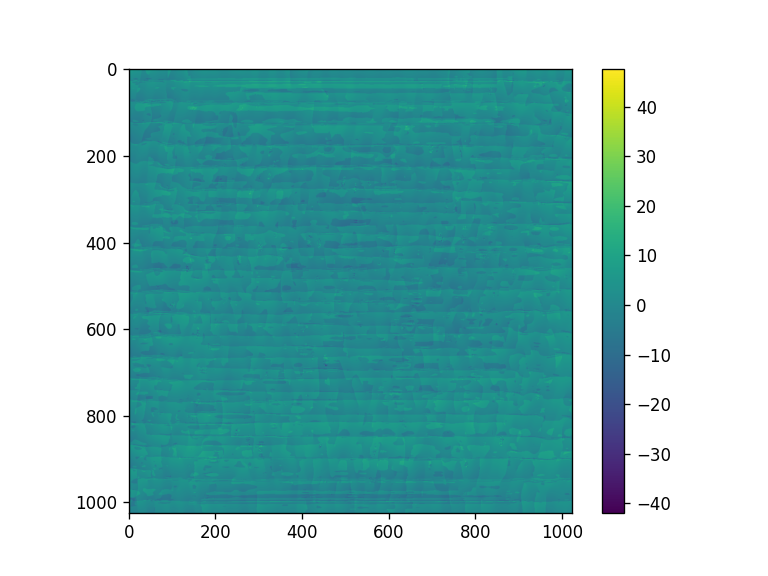

In [37]:
solution = moe.optimizer.optimize(FOM3, x0= xvalues.flatten(), args1=[mask2, screen, wavelength, matrix], verbose = 1, ftol=1e-6, xtol=None,\
                                  optimizer_method='dogbox' )


x2 = solution.x

fig = plt.figure() 
xar = np.reshape(x2, (x_pixel, y_pixel))
plt.imshow(xar) 
plt.colorbar()

Elapsed: 0:00:00.625756
Elapsed: 0:00:00.612812


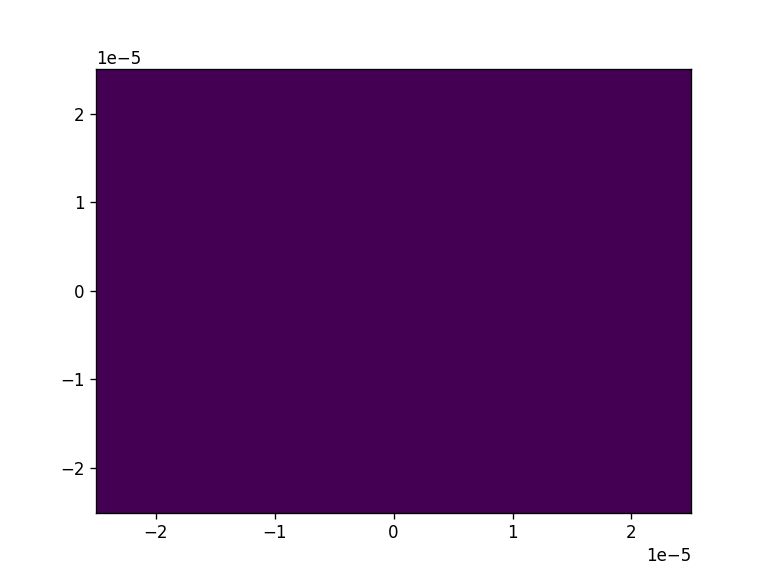

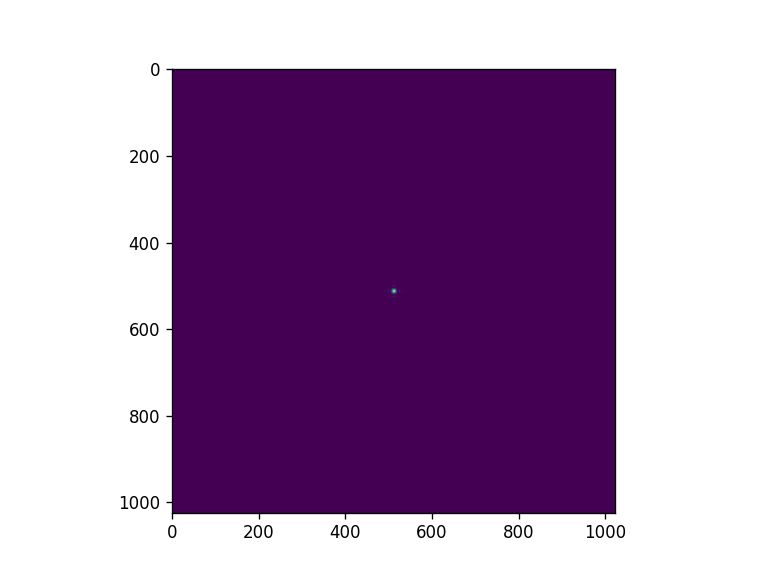

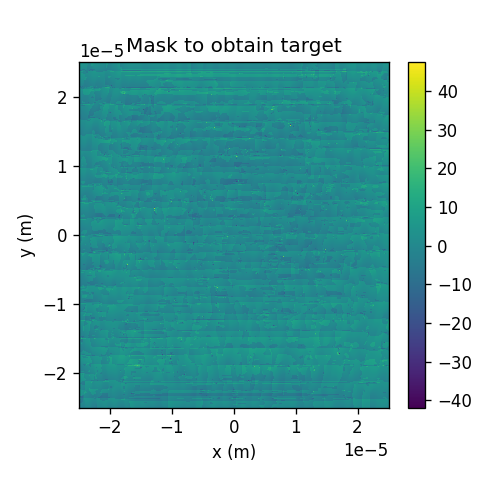

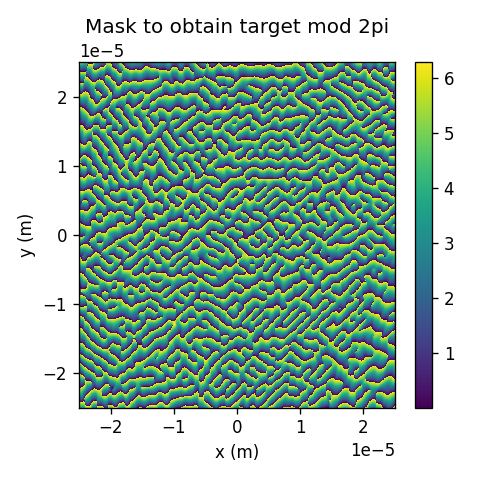

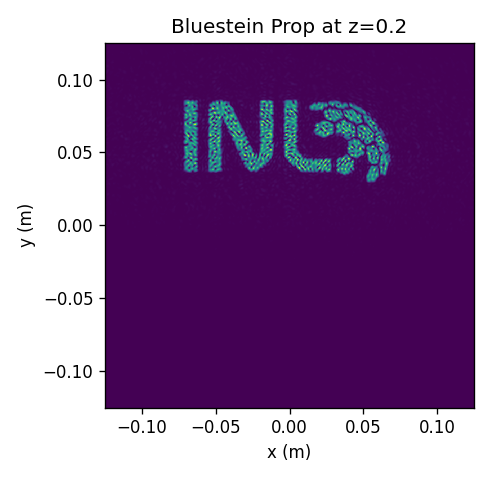

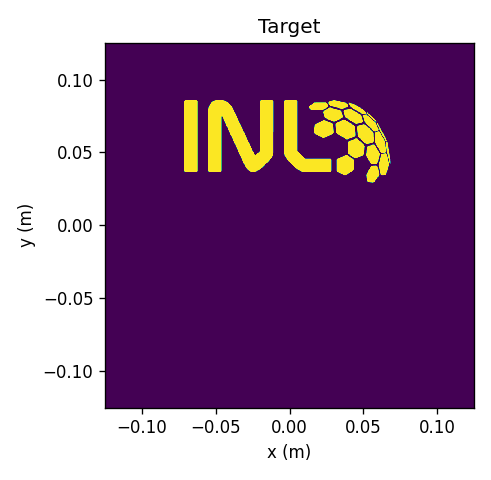

In [38]:
fig = plt.figure() 
xar2 = np.reshape(x0_flatten, (x_pixel, y_pixel))
#plt.imshow(xar2) 
plt.pcolormesh(mask2.x, mask2.y, xar2)

fig = plt.figure() 
plt.imshow(np.abs(moe.optimizer.propagate(xar2, mask2, screen, wavelength) )**2 )


fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x2, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3), axis=1)) 
plt.title("Mask to obtain target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()




fig = plt.figure(figsize=(4.1,4)) 
xar3 = np.reshape(x2, (x_pixel, y_pixel))
plt.pcolormesh(mask2.x, mask2.y, np.flip(np.flip(xar3)%(2*np.pi), axis=1)) 
plt.title("Mask to obtain target mod 2pi")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.colorbar()
plt.tight_layout()



fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x, screen.y, np.flip(np.flip(np.abs(moe.optimizer.propagate(xar3, mask2, screen, wavelength) )**2 ) , axis=1))
plt.title("Bluestein Prop at z="+str(screen.z[-1]))
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()

fig = plt.figure(figsize=(4.1,4)) 
plt.pcolormesh(screen.x,screen.y, np.flip(np.flip(np.reshape(matrix, (x_pixel, y_pixel)) ) ,axis =1))
plt.title("Target")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()